# Weather-Based AQI Prediction — Complete Analysis
**American University of Phnom Penh**

Team: Chhin Sokhom Sidhisakdeh & Sam Chankroesna

---
## Notebook Structure

### PART 1 — Data Collection & Cleaning
### PART 2 — Descriptive Statistics
### PART 3 — Data Visualization
### PART 4 — Exploratory Data Analysis (EDA)
### PART 5 — Hypothesis Testing (Correlation, Regression, Chi-Square)
### PART 6 — Time Series Analysis
### PART 7 — Machine Learning Models (LSTM & GRU)
### PART 8 — Findings & Recommendations

---
#SETUP — Install & Import All Libraries

In [ ]:
!pip install scikit-learn tensorflow pandas numpy matplotlib seaborn scipy statsmodels -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Statistics
from scipy import stats
from scipy.stats import chi2_contingency, pearsonr, spearmanr, shapiro
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine Learning
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print(f'TensorFlow: {tf.__version__}')
print('All libraries loaded successfully!')

TensorFlow: 2.19.0
All libraries loaded successfully!


---
# PART 1 — Data Collection & Cleaning

## 1.1 — Upload & Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

df_raw = pd.read_csv('Beijing Multisite air Quality data.csv')
print(f'Dataset shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
print(f'Stations ({df_raw["station"].nunique()}): {sorted(df_raw["station"].unique())}')
print(f'Years: {df_raw["year"].min()} - {df_raw["year"].max()}')
df_raw.head()

Dataset shape: (264202, 17)
Columns: ['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']
Stations (9): ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhan', 'Nongzhanguan']
Years: 2013 - 2017


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


## 1.2 — Data Cleaning

In [ ]:
df = df_raw.copy()

# --- Missing values before cleaning ---
print('=== Missing Values Before Cleaning ===')
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])
print(f'Total missing: {df.isnull().sum().sum()}')

# --- Create datetime ---
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.sort_values(['station', 'datetime']).reset_index(drop=True)

# --- Encode station ---
le = LabelEncoder()
df['station_enc'] = le.fit_transform(df['station'])
station_names = le.classes_

# --- Encode wind direction ---
wind_map = {
    'N': 0, 'NNE': 1, 'NE': 2, 'ENE': 3, 'E': 4, 'ESE': 5,
    'SE': 6, 'SSE': 7, 'S': 8, 'SSW': 9, 'SW': 10, 'WSW': 11,
    'W': 12, 'WNW': 13, 'NW': 14, 'NNW': 15
}
df['wd'] = df['wd'].map(wind_map)

# --- Forward fill per station ---
df = df.groupby('station', group_keys=False).apply(lambda g: g.ffill().bfill())

print('\n=== Missing Values After Cleaning ===')
print(f'Total missing: {df.isnull().sum().sum()}')

# --- Check for duplicates ---
dupes = df.duplicated(subset=['datetime', 'station_enc']).sum()
print(f'Duplicate timestamps per station: {dupes}')

print('\nData cleaning complete.')
df.head()

=== Missing Values Before Cleaning ===
PM2.5     5721
PM10      4310
SO2       5133
NO2       7884
CO       13912
O3        7518
TEMP       270
PRES       265
DEWP       272
RAIN       262
wd         983
WSPM       221
dtype: int64
Total missing: 46751

=== Missing Values After Cleaning ===
Total missing: 0
Duplicate timestamps per station: 0

Data cleaning complete.


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,station_enc
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,15.0,4.4,Aotizhongxin,2013-03-01 00:00:00,0
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,0.0,4.7,Aotizhongxin,2013-03-01 01:00:00,0
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,15.0,5.6,Aotizhongxin,2013-03-01 02:00:00,0
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,14.0,3.1,Aotizhongxin,2013-03-01 03:00:00,0
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,0.0,2.0,Aotizhongxin,2013-03-01 04:00:00,0


## 1.3 — AQI Calculation from PM2.5 (US EPA Breakpoints 2026)

In [ ]:
def pm25_to_aqi(pm25):
    breakpoints = [
        (0.0,   9.0,   0,   50),
        (9.1,   35.4,  51,  100),
        (35.5,  55.4,  101, 150),
        (55.5,  125.4, 151, 200),
        (125.5, 225.4, 201, 300),
        (225.5, 325.4, 301, 400),
        (325.5, 500.4, 401, 500),
    ]
    if pm25 < 0: return 0
    for c_lo, c_hi, i_lo, i_hi in breakpoints:
        if c_lo <= pm25 <= c_hi:
            return round(((i_hi - i_lo) / (c_hi - c_lo)) * (pm25 - c_lo) + i_lo)
    return 500

def aqi_category(aqi):
    if aqi <= 50:    return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200: return 'Unhealthy'
    elif aqi <= 300: return 'Very Unhealthy'
    else:            return 'Hazardous'

df['AQI'] = df['PM2.5'].apply(pm25_to_aqi)
df['AQI_Category'] = df['AQI'].apply(aqi_category)

# Add time features for analysis
df['month']  = df['datetime'].dt.month
df['year']   = df['datetime'].dt.year
df['hour_of_day'] = df['datetime'].dt.hour
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring',  4: 'Spring', 5: 'Spring',
    6: 'Summer',  7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})
df['station_name'] = le.inverse_transform(df['station_enc'].astype(int))

print('AQI Category Distribution (All Stations):')
print(df['AQI_Category'].value_counts())
print(f'\nAQI Range: {df["AQI"].min()} - {df["AQI"].max()}')

# Save cleaned data for Excel dashboard
df.to_csv('Beijing_AQI_Cleaned.csv', index=False)

# Download cleaned data
from google.colab import files
files.download('Beijing_AQI_Cleaned.csv')

AQI Category Distribution (All Stations):
AQI_Category
Unhealthy                         75656
Moderate                          73043
Very Unhealthy                    38236
Unhealthy for Sensitive Groups    34176
Good                              27199
Hazardous                         15892
Name: count, dtype: int64

AQI Range: 11 - 500


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# PART 2 — Descriptive Statistics

In [ ]:
NUMERIC_COLS = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'AQI']

print('=== Descriptive Statistics (All Stations Combined) ===')
desc = df[NUMERIC_COLS].describe().T
desc['skewness'] = df[NUMERIC_COLS].skew()
desc['kurtosis'] = df[NUMERIC_COLS].kurt()

# Add mode (rubric requirement)
desc['mode'] = df[NUMERIC_COLS].mode().iloc[0]

# Reorder columns for readability
col_order = ['count', 'mean', '50%', 'mode', 'std', 'min', 'max', 'skewness', 'kurtosis']
col_order = [c for c in col_order if c in desc.columns]
desc = desc[col_order]
desc.index.name = 'Feature'
print(desc.round(3).to_string())

print('\n=== Average AQI Per Station ===')
station_stats = df.groupby('station_name')['AQI'].agg(['mean','median','std','min','max'])
station_stats.columns = ['Mean AQI','Median AQI','Std Dev','Min','Max']
print(station_stats.round(2).sort_values('Mean AQI', ascending=False).to_string())

print('\n=== Average AQI Per Season ===')
print(df.groupby('season')['AQI'].agg(['mean','median','std']).round(2))

print('\n=== Average AQI Per Year ===')
print(df.groupby('year')['AQI'].agg(['mean','median','std']).round(2))


=== Descriptive Statistics (All Stations Combined) ===
            count      mean     50%    mode       std      min      max  skewness  kurtosis
Feature                                                                                    
PM2.5    264202.0    78.776    54.0     3.0    79.869    2.000    898.0     1.995     5.762
PM10     264202.0   104.152    81.0     6.0    91.879    2.000    999.0     1.927     6.720
SO2      264202.0    16.191     7.0     2.0    22.822    0.286    500.0     4.147    43.296
NO2      264202.0    48.008    40.0     2.0    34.985    1.026    290.0     1.085     1.284
CO       264202.0  1201.377   900.0   300.0  1128.859  100.000  10000.0     2.621    10.079
O3       264202.0    59.400    47.0     2.0    58.782    0.214   1071.0     2.056    10.623
TEMP     264202.0    13.488    14.4     3.0    11.420  -19.900     41.6    -0.101    -1.132
PRES     264202.0  1009.932  1009.6  1019.0    10.428  982.400   1042.0     0.101    -0.830
DEWP     264202.0     2.3

---
# PART 3 — Data Visualization

## 3.1 — AQI Overview Plots

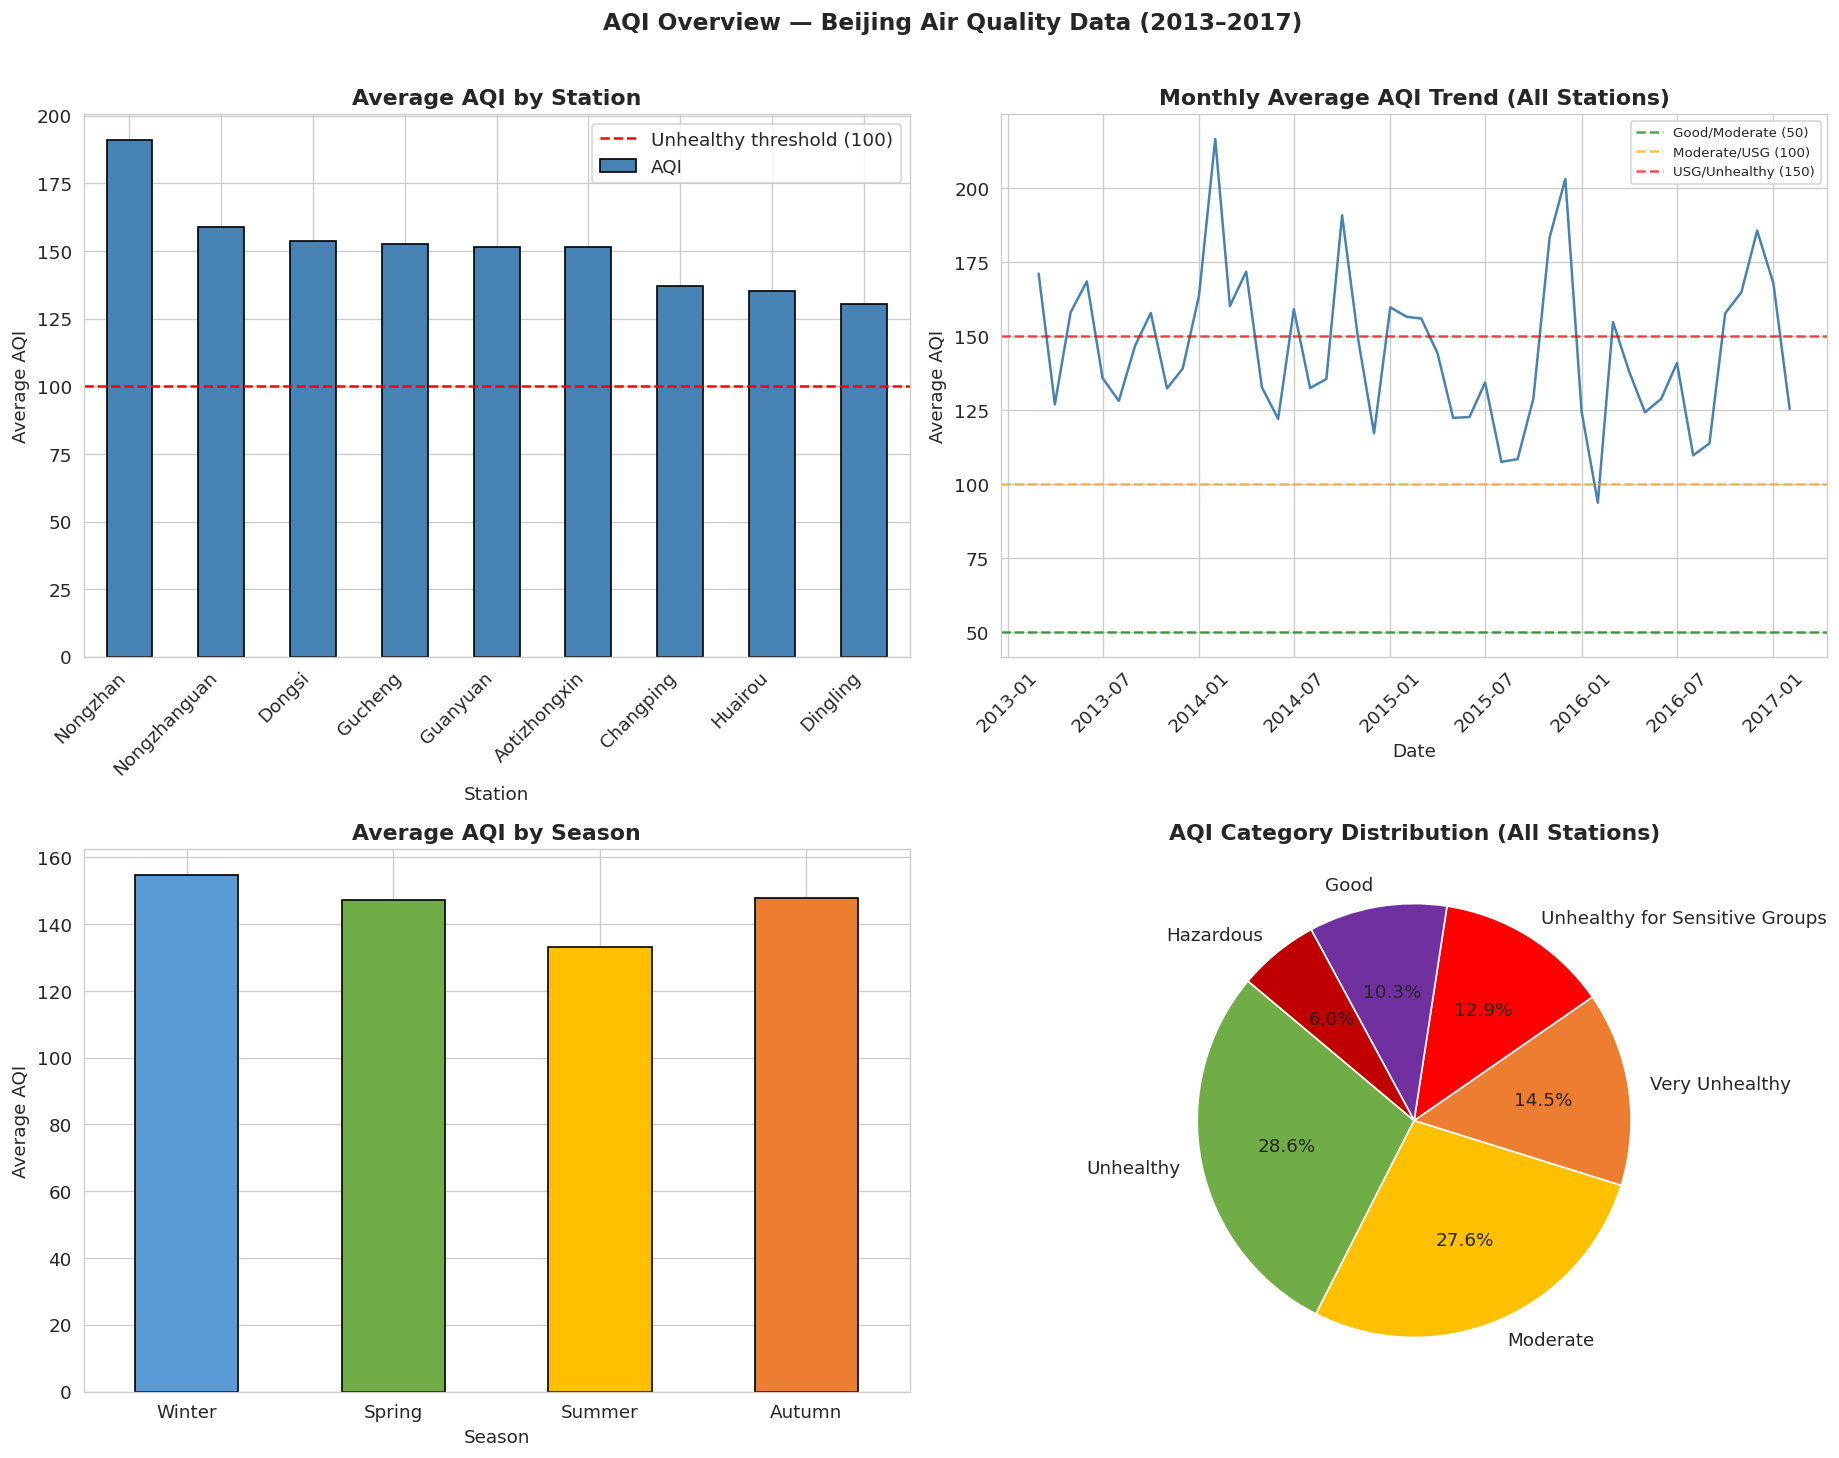

Saved: viz_overview.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average AQI per station
ax = axes[0, 0]
station_avg = df.groupby('station_name')['AQI'].mean().sort_values(ascending=False)
station_avg.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.axhline(100, color='red', linestyle='--', label='Unhealthy threshold (100)')
ax.set_title('Average AQI by Station', fontweight='bold')
ax.set_xlabel('Station'); ax.set_ylabel('Average AQI')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend()

# Plot 2: Monthly AQI trend
ax = axes[0, 1]
monthly = df.groupby(['year', 'month'])['AQI'].mean().reset_index()
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
ax.plot(monthly['date'], monthly['AQI'], color='steelblue', linewidth=1.5)
ax.axhline(50,  color='green',  linestyle='--', alpha=0.7, label='Good/Moderate (50)')
ax.axhline(100, color='orange', linestyle='--', alpha=0.7, label='Moderate/USG (100)')
ax.axhline(150, color='red',    linestyle='--', alpha=0.7, label='USG/Unhealthy (150)')
ax.set_title('Monthly Average AQI Trend (All Stations)', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Average AQI')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=45)

# Plot 3: Seasonal AQI
ax = axes[1, 0]
season_order  = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = ['#5b9bd5', '#70ad47', '#ffc000', '#ed7d31']
df.groupby('season')['AQI'].mean().reindex(season_order).plot(
    kind='bar', ax=ax, color=season_colors, edgecolor='black')
ax.set_title('Average AQI by Season', fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Average AQI')
ax.set_xticklabels(season_order, rotation=0)

# Plot 4: AQI category pie
ax = axes[1, 1]
cat_counts = df['AQI_Category'].value_counts()
colors_pie = ['#70ad47', '#ffc000', '#ed7d31', '#ff0000', '#7030a0', '#c00000']
ax.pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
       colors=colors_pie[:len(cat_counts)], startangle=140)
ax.set_title('AQI Category Distribution (All Stations)', fontweight='bold')

plt.suptitle('AQI Overview — Beijing Air Quality Data (2013–2017)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_overview.png')

## 3.2 — Monthly AQI Heatmap (Year × Month)

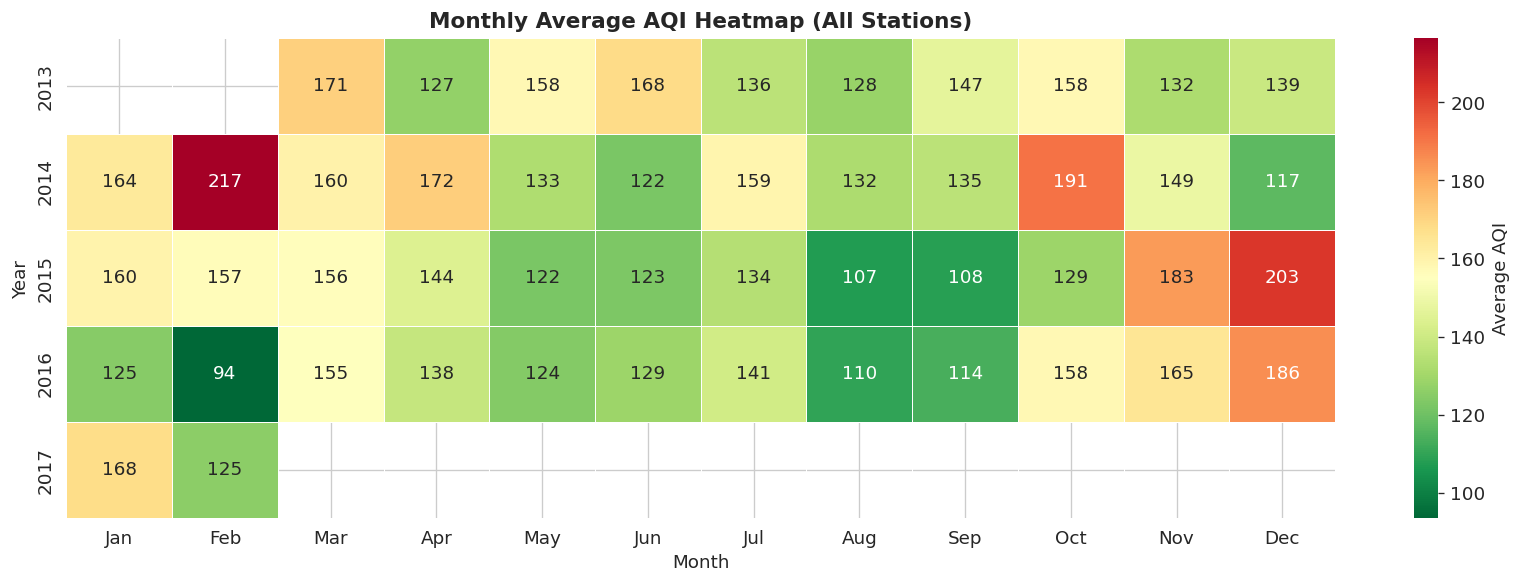

Saved: viz_heatmap.png


In [ ]:
pivot = df.groupby(['year', 'month'])['AQI'].mean().unstack()
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Average AQI'})
plt.title('Monthly Average AQI Heatmap (All Stations)', fontweight='bold', fontsize=13)
plt.xlabel('Month'); plt.ylabel('Year')
plt.tight_layout()
plt.savefig('viz_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_heatmap.png')

## 3.3 — Per-Station AQI Boxplot

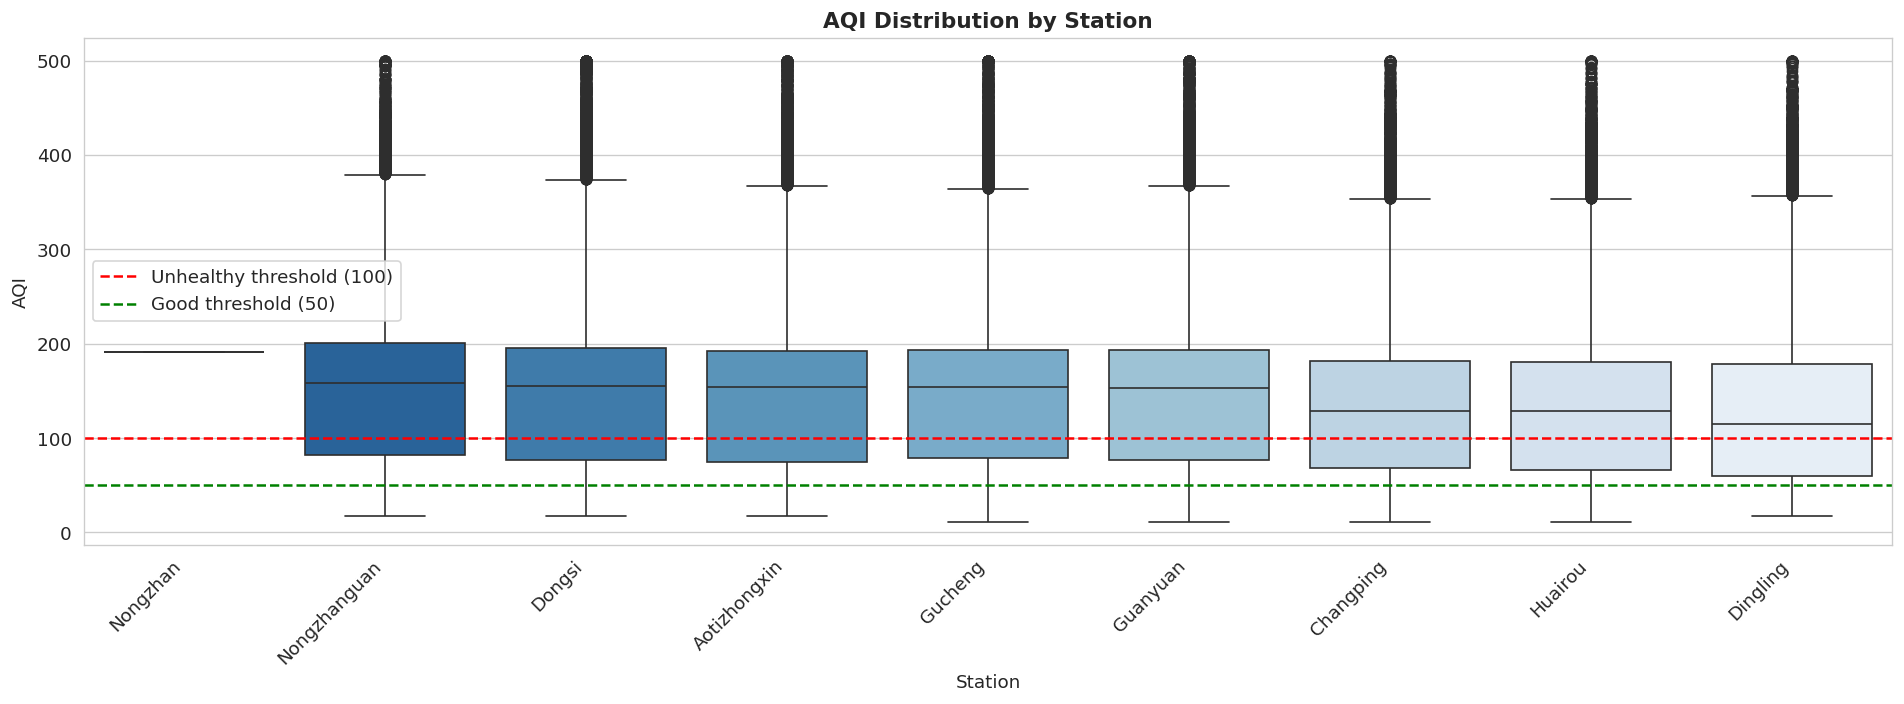

Saved: viz_station_boxplot.png


In [ ]:
plt.figure(figsize=(16, 6))
station_order = df.groupby('station_name')['AQI'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='station_name', y='AQI', order=station_order, palette='Blues_r')
plt.axhline(100, color='red',   linestyle='--', label='Unhealthy threshold (100)')
plt.axhline(50,  color='green', linestyle='--', label='Good threshold (50)')
plt.title('AQI Distribution by Station', fontweight='bold', fontsize=13)
plt.xlabel('Station'); plt.ylabel('AQI')
plt.xticks(rotation=45, ha='right')
plt.legend(); plt.tight_layout()
plt.savefig('viz_station_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_station_boxplot.png')

## 3.4 — Hourly AQI Pattern (Average by Hour of Day)

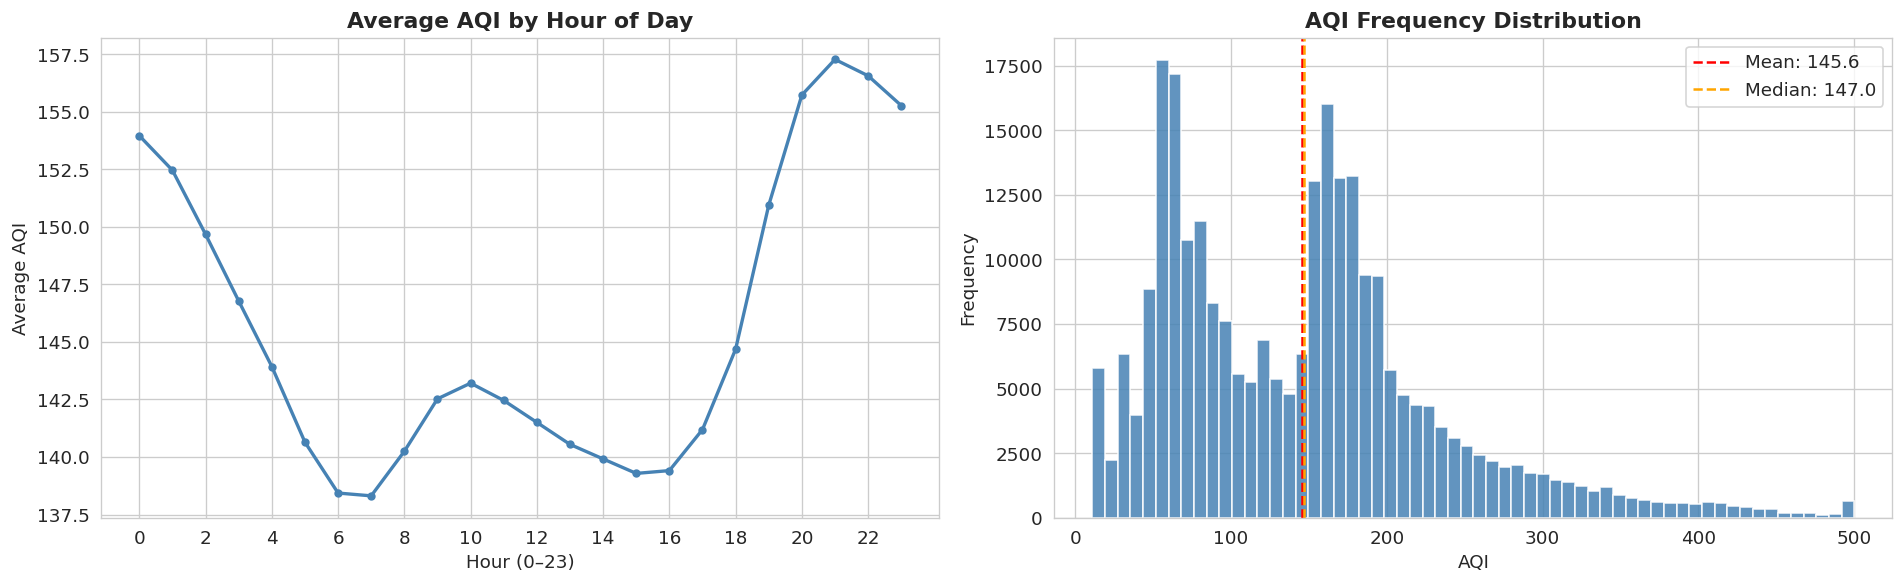

Saved: viz_hourly_dist.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hourly pattern
ax = axes[0]
hourly = df.groupby('hour_of_day')['AQI'].mean()
ax.plot(hourly.index, hourly.values, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.set_title('Average AQI by Hour of Day', fontweight='bold')
ax.set_xlabel('Hour (0–23)'); ax.set_ylabel('Average AQI')
ax.set_xticks(range(0, 24, 2))

# AQI distribution histogram
ax = axes[1]
ax.hist(df['AQI'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['AQI'].mean(),   color='red',    linestyle='--', label=f'Mean: {df["AQI"].mean():.1f}')
ax.axvline(df['AQI'].median(), color='orange', linestyle='--', label=f'Median: {df["AQI"].median():.1f}')
ax.set_title('AQI Frequency Distribution', fontweight='bold')
ax.set_xlabel('AQI'); ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.savefig('viz_hourly_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_hourly_dist.png')

## 3.5 — Pollutant Trends Over Time

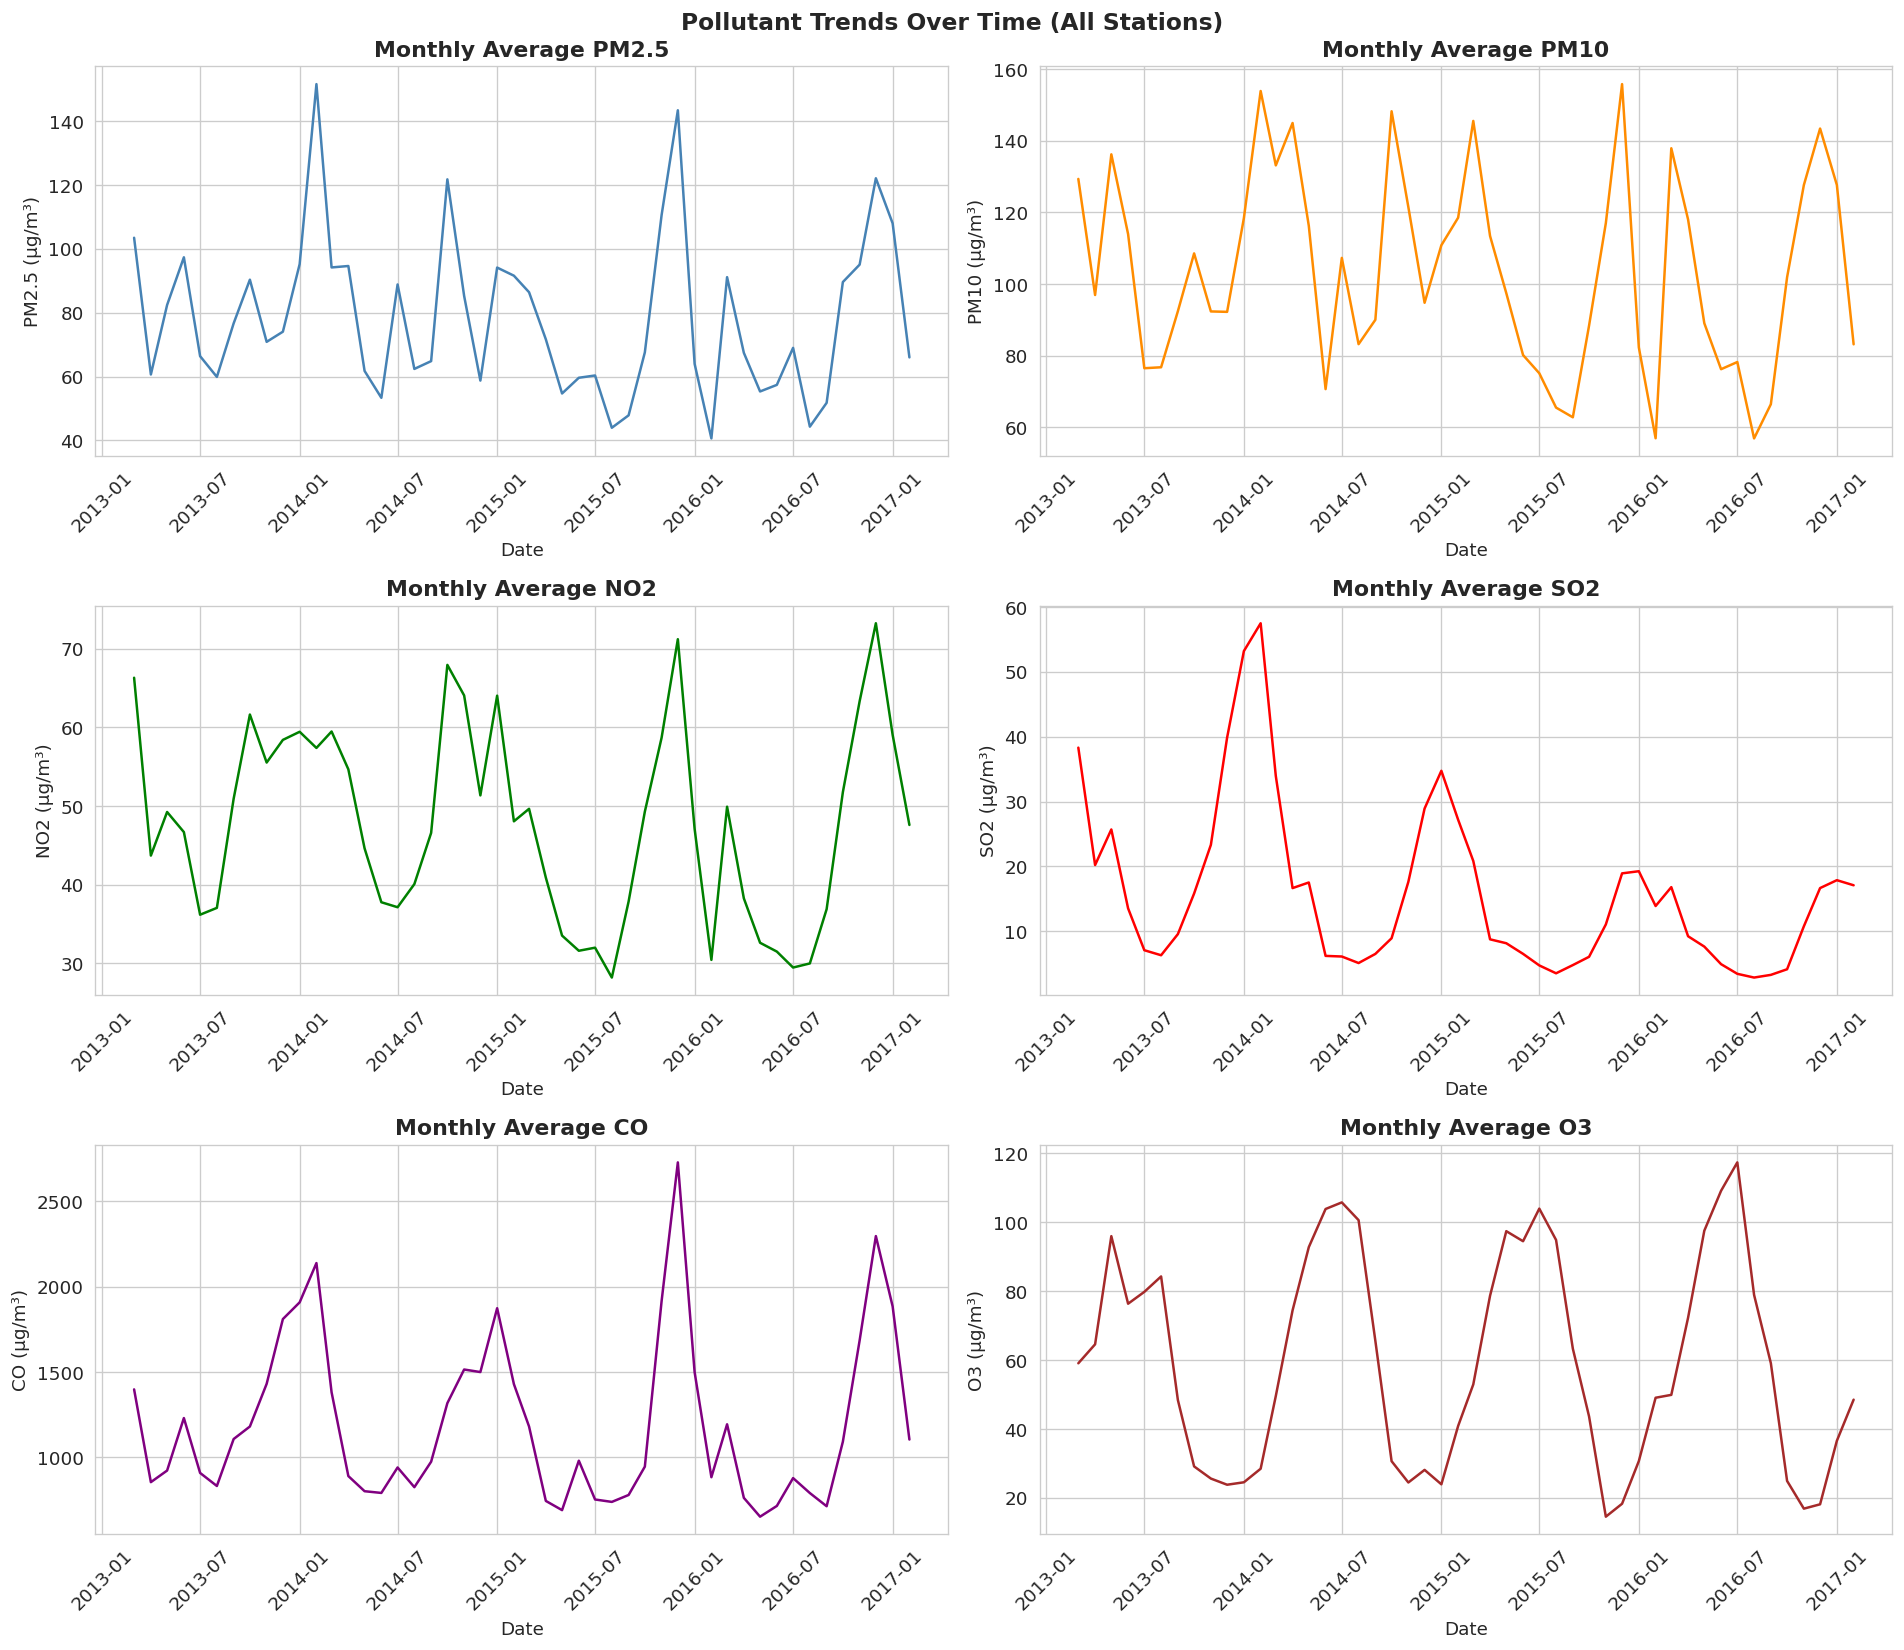

Saved: viz_pollutant_trends.png


In [ ]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
monthly_poll = df.groupby(['year', 'month'])[pollutants].mean().reset_index()
monthly_poll['date'] = pd.to_datetime(monthly_poll[['year', 'month']].assign(day=1))

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple', 'brown']

for i, (poll, color) in enumerate(zip(pollutants, colors)):
    axes[i].plot(monthly_poll['date'], monthly_poll[poll], color=color, linewidth=1.5)
    axes[i].set_title(f'Monthly Average {poll}', fontweight='bold')
    axes[i].set_xlabel('Date'); axes[i].set_ylabel(f'{poll} (µg/m³)')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Pollutant Trends Over Time (All Stations)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_pollutant_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_pollutant_trends.png')

---
# PART 4 — Exploratory Data Analysis (EDA)

##Feature Correlation Matrix

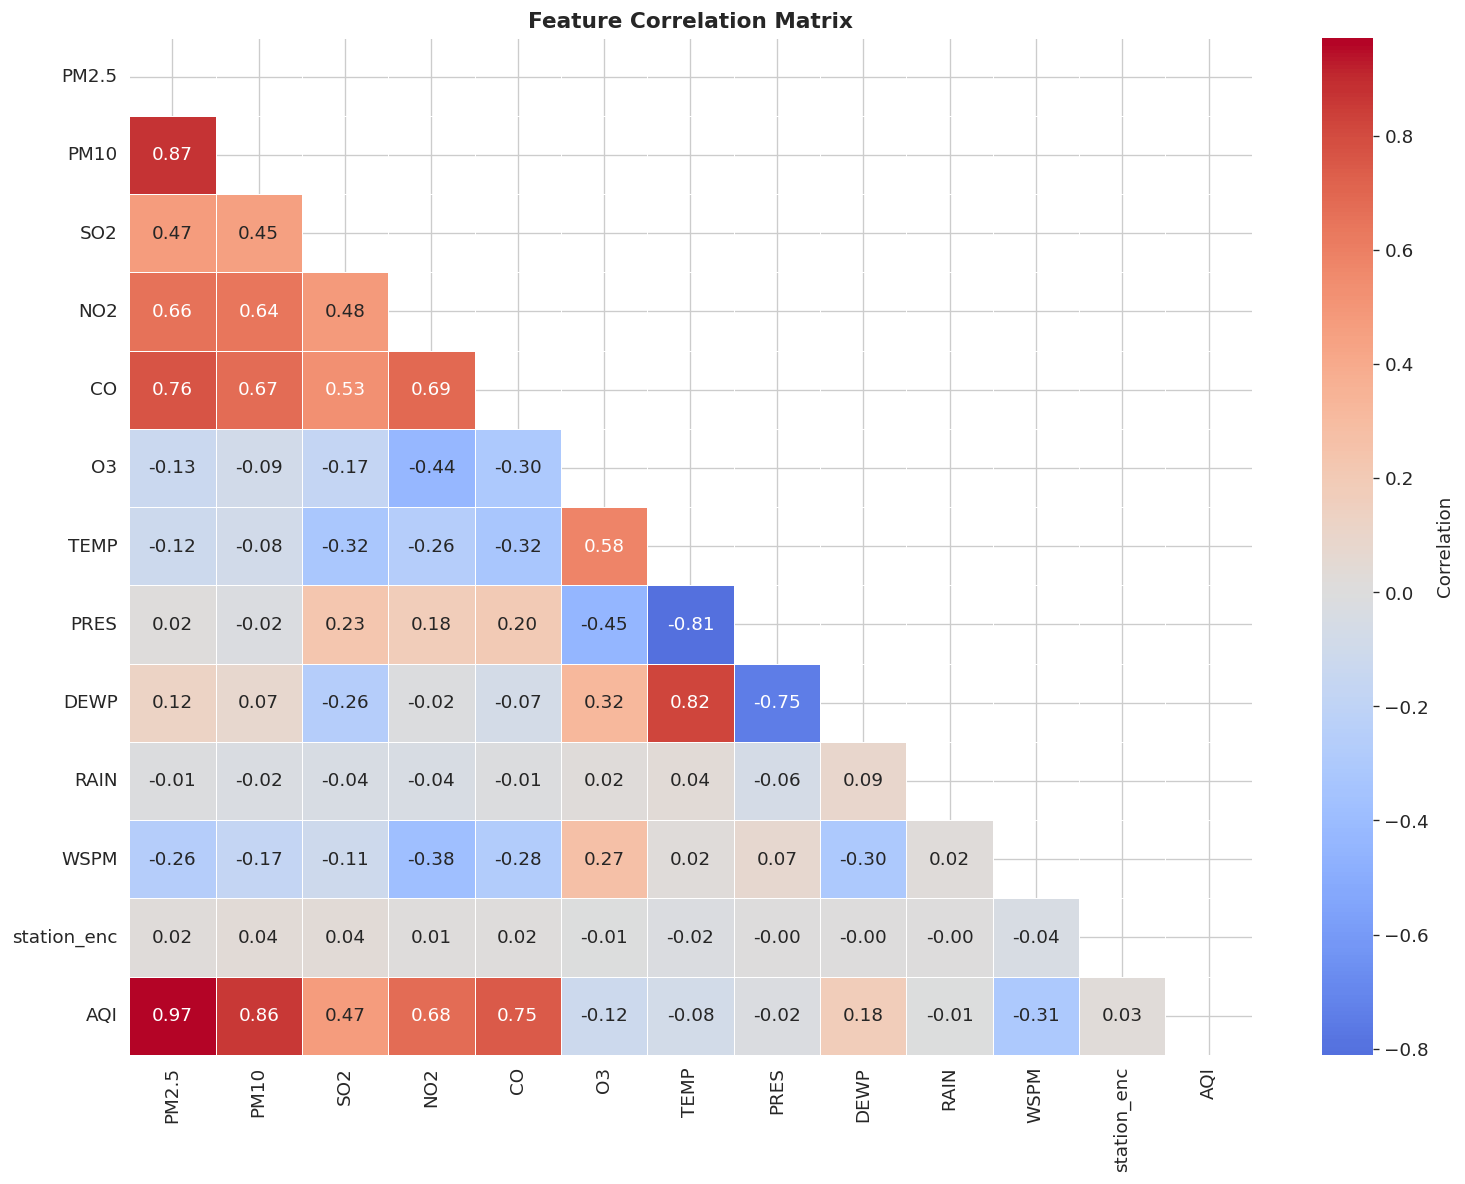

Saved: eda_correlation_matrix.png

Top correlations with AQI:
PM2.5          0.972
PM10           0.859
CO             0.745
NO2            0.676
SO2            0.474
DEWP           0.183
station_enc    0.026
RAIN          -0.009
PRES          -0.021
TEMP          -0.075
O3            -0.117
WSPM          -0.309
Name: AQI, dtype: float64


In [ ]:
FEATURES = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
            'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'station_enc', 'AQI']

corr = df[FEATURES].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_correlation_matrix.png')

print('\nTop correlations with AQI:')
print(corr['AQI'].drop('AQI').sort_values(ascending=False).round(3))

---
# PART 5 — Hypothesis Testing

## 5.1 — Pearson Correlation Analysis
**H0:** There is no significant linear correlation between meteorological variables and AQI.

**H1:** Meteorological variables are significantly correlated with AQI.

In [ ]:
print('=== Pearson Correlation with AQI ===')
print(f'{"Feature":<12} {"r (effect size)":>18} {"p-value":>12} {"Significant":>12} {"Effect Magnitude":>18}')
print('-' * 75)

test_features = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

def effect_magnitude(r):
    r = abs(r)
    if r >= 0.5:   return 'Large'
    elif r >= 0.3: return 'Medium'
    elif r >= 0.1: return 'Small'
    else:          return 'Negligible'

corr_results = []
for feat in test_features:
    r, p = pearsonr(df[feat].dropna(), df.loc[df[feat].notna(), 'AQI'])
    sig = 'Yes' if p < 0.05 else 'No'
    mag = effect_magnitude(r)
    corr_results.append({'Feature': feat, 'r': r, 'p-value': p, 'Significant': sig, 'Effect': mag})
    print(f'{feat:<12} {r:>18.4f} {p:>12.4e} {sig:>12} {mag:>18}')

print('\nNote: |r| >= 0.5 = Large, >= 0.3 = Medium, >= 0.1 = Small effect (Cohen, 1988)')
print('Interpretation: Features with p < 0.05 reject H0 — significant correlation with AQI.')


=== Pearson Correlation with AQI ===
Feature         r (effect size)      p-value  Significant   Effect Magnitude
---------------------------------------------------------------------------
PM2.5                    0.9717   0.0000e+00          Yes              Large
PM10                     0.8587   0.0000e+00          Yes              Large
SO2                      0.4743   0.0000e+00          Yes             Medium
NO2                      0.6761   0.0000e+00          Yes              Large
CO                       0.7450   0.0000e+00          Yes              Large
O3                      -0.1166   0.0000e+00          Yes              Small
TEMP                    -0.0755   0.0000e+00          Yes         Negligible
PRES                    -0.0214   3.8901e-28          Yes         Negligible
DEWP                     0.1834   0.0000e+00          Yes              Small
RAIN                    -0.0086   1.1045e-05          Yes         Negligible
WSPM                    -0.3087   0.0000

## 5.2 — Multiple Linear Regression
**H0:** Meteorological variables do not significantly predict AQI.

**H1:** Meteorological variables are significant predictors of AQI.

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                 9.659e+04
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:23:21   Log-Likelihood:            -2.1710e+05
No. Observations:               50000   AIC:                         4.342e+05
Df Residuals:                   49988   BIC:                         4.343e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.2993     14.505      3.261      0.0

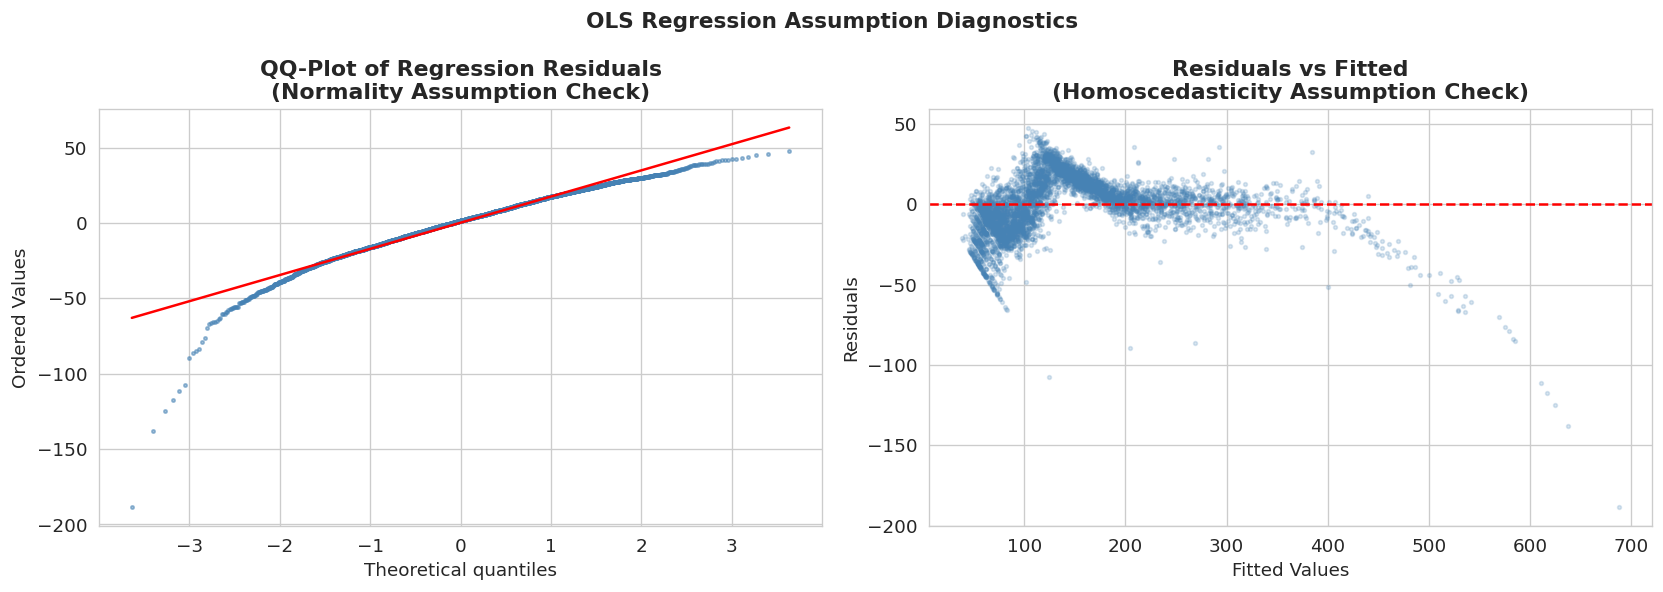

Saved: hypothesis_regression_assumptions.png


In [ ]:
reg_features = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Sample for speed
sample_reg = df[reg_features + ['AQI']].sample(50000, random_state=42).dropna()
X_reg = sm.add_constant(sample_reg[reg_features])
y_reg = sample_reg['AQI']

model_ols = sm.OLS(y_reg, X_reg).fit()
print(model_ols.summary())

print('\n=== Key Regression Metrics ===')
print(f'R²:          {model_ols.rsquared:.4f}')
print(f'Adjusted R²: {model_ols.rsquared_adj:.4f}')
print(f'F-statistic: {model_ols.fvalue:.2f} (p={model_ols.f_pvalue:.4e})')
print('\nConclusion: If F-statistic p < 0.05, we reject H0 — the model is statistically significant.')

# --- Confidence Intervals ---
print('\n=== 95% Confidence Intervals for Regression Coefficients ===')
ci = model_ols.conf_int(alpha=0.05)
ci.columns = ['CI Lower (2.5%)', 'CI Upper (97.5%)']
ci['Coefficient'] = model_ols.params
ci = ci[['Coefficient', 'CI Lower (2.5%)', 'CI Upper (97.5%)']]
print(ci.round(4).to_string())
print('\nNote: Intervals that do not cross zero indicate a significant predictor at α=0.05.')

# --- Assumption Checks ---
print('\n=== Regression Assumption Checks ===')

y_fitted   = model_ols.fittedvalues
residuals  = model_ols.resid

# Normality of residuals (Shapiro-Wilk on a subsample — full 50k too large)
resid_sample = residuals.sample(5000, random_state=42)
stat_sw, p_sw = stats.shapiro(resid_sample)
print(f'Shapiro-Wilk normality test on residuals (n=5000):')
print(f'  W={stat_sw:.4f}, p={p_sw:.4e}')
print(f'  {"Residuals approximately normal" if p_sw > 0.05 else "Residuals deviate from normality (common with large N — inspect QQ-plot)"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ-plot
ax = axes[0]
stats.probplot(residuals.sample(5000, random_state=42), dist='norm', plot=ax)
ax.set_title('QQ-Plot of Regression Residuals\n(Normality Assumption Check)', fontweight='bold')
ax.get_lines()[0].set(color='steelblue', alpha=0.5, markersize=2)
ax.get_lines()[1].set(color='red')

# Residuals vs Fitted (Homoscedasticity)
ax = axes[1]
ax.scatter(y_fitted.sample(5000, random_state=42),
           residuals.loc[y_fitted.sample(5000, random_state=42).index],
           alpha=0.2, s=5, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted\n(Homoscedasticity Assumption Check)', fontweight='bold')

plt.suptitle('OLS Regression Assumption Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hypothesis_regression_assumptions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hypothesis_regression_assumptions.png')


## 5.3 — Chi-Square Test (AQI Category vs Season)
**H0:** AQI health risk category is independent of season.

**H1:** AQI health risk category is dependent on season.

=== Contingency Table: Season vs AQI Category ===
AQI_Category  Good  Hazardous  Moderate  Unhealthy  \
season                                               
Autumn        7586       4972     17455      17615   
Spring        5332       3180     17031      22206   
Summer        5141        691     20168      21457   
Winter        9140       7049     18389      14378   

AQI_Category  Unhealthy for Sensitive Groups  Very Unhealthy  
season                                                        
Autumn                                  8277            9615  
Spring                                  9866            9859  
Summer                                 10750            8033  
Winter                                  5283           10729  

=== Chi-Square Test Results ===
Chi-Square Statistic: 11958.2009
Degrees of Freedom:   15
P-value:              0.0000e+00
Cramér's V (effect size): 0.1228 → Small effect

Conclusion: Reject H0 — AQI category IS dependent on season.
Note: Cramér'

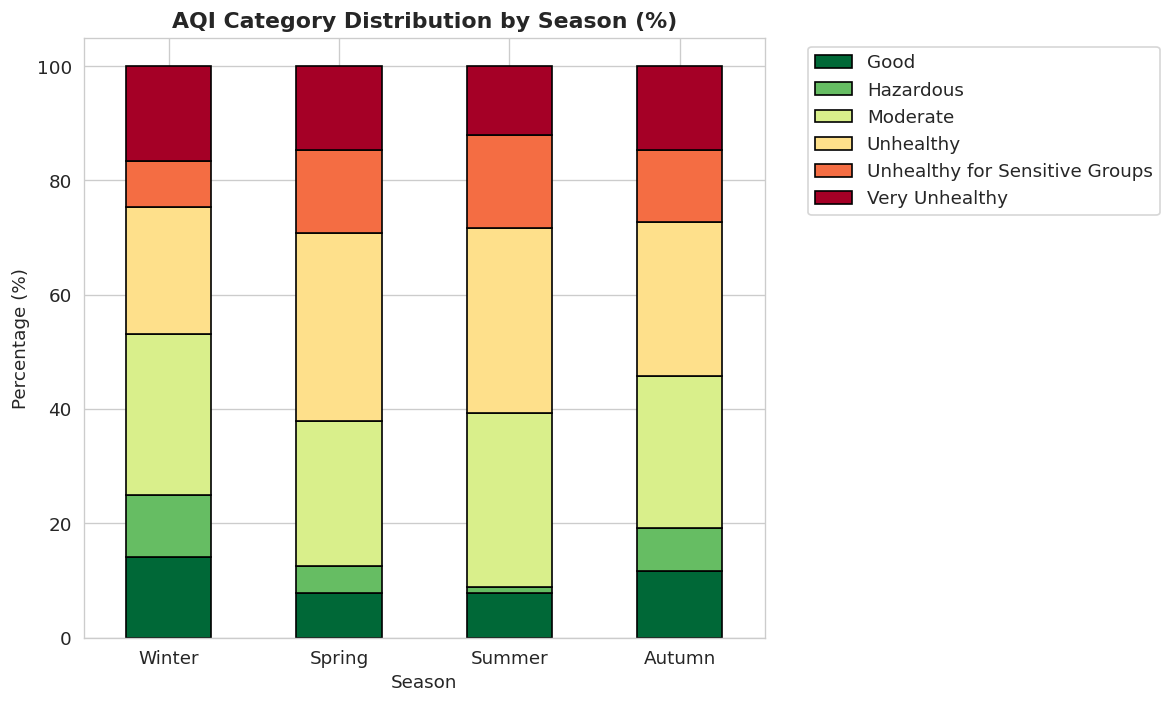

Saved: hypothesis_chi2.png


In [ ]:
# Contingency table: season vs AQI category
contingency = pd.crosstab(df['season'], df['AQI_Category'])
print('=== Contingency Table: Season vs AQI Category ===')
print(contingency)

chi2, p_chi2, dof, expected = chi2_contingency(contingency)

# Cramér's V — effect size for Chi-Square
n      = contingency.values.sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

def cramers_magnitude(v):
    if v >= 0.5:   return 'Large'
    elif v >= 0.3: return 'Medium'
    elif v >= 0.1: return 'Small'
    else:          return 'Negligible'

print(f'\n=== Chi-Square Test Results ===')
print(f'Chi-Square Statistic: {chi2:.4f}')
print(f'Degrees of Freedom:   {dof}')
print(f'P-value:              {p_chi2:.4e}')
print(f"Cramér's V (effect size): {cramers_v:.4f} → {cramers_magnitude(cramers_v)} effect")
print(f'\nConclusion: {"Reject H0 — AQI category IS dependent on season." if p_chi2 < 0.05 else "Fail to reject H0."}')
print("Note: Cramér's V ranges from 0 (no association) to 1 (perfect association).")

# Visualize
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
contingency_pct.reindex(['Winter', 'Spring', 'Summer', 'Autumn']).plot(
    kind='bar', stacked=True, figsize=(10, 6),
    colormap='RdYlGn_r', edgecolor='black')
plt.title('AQI Category Distribution by Season (%)', fontweight='bold')
plt.xlabel('Season'); plt.ylabel('Percentage (%)')
plt.xticks(rotation=0); plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('hypothesis_chi2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hypothesis_chi2.png')


## 5.4 — One-Way ANOVA: AQI Across Seasons
**H0:** Mean AQI is equal across all seasons.

**H1:** At least one season has a significantly different mean AQI.

In [ ]:
winter = df[df['season'] == 'Winter']['AQI']
spring = df[df['season'] == 'Spring']['AQI']
summer = df[df['season'] == 'Summer']['AQI']
autumn = df[df['season'] == 'Autumn']['AQI']

f_stat, p_anova = stats.f_oneway(winter, spring, summer, autumn)

# Eta-squared — effect size for ANOVA
all_groups  = pd.concat([winter, spring, summer, autumn])
grand_mean  = all_groups.mean()
ss_between  = sum(len(g) * (g.mean() - grand_mean)**2 for g in [winter, spring, summer, autumn])
ss_total    = ((all_groups - grand_mean)**2).sum()
eta_squared = ss_between / ss_total

def eta_magnitude(eta2):
    if eta2 >= 0.14:  return 'Large'
    elif eta2 >= 0.06: return 'Medium'
    elif eta2 >= 0.01: return 'Small'
    else:              return 'Negligible'

print('=== One-Way ANOVA: AQI ~ Season ===')
print(f'F-statistic:           {f_stat:.4f}')
print(f'P-value:               {p_anova:.4e}')
print(f'Eta-squared (η²):      {eta_squared:.4f} → {eta_magnitude(eta_squared)} effect')
print(f'\nConclusion: {"Reject H0 — Significant AQI differences exist between seasons." if p_anova < 0.05 else "Fail to reject H0."}')
print('Note: η² represents the proportion of total AQI variance explained by season.')

print('\nSeasonal Mean AQI:')
for season, data in [('Winter', winter), ('Spring', spring),
                      ('Summer', summer), ('Autumn', autumn)]:
    print(f'  {season}: {data.mean():.2f}')


=== One-Way ANOVA: AQI ~ Season ===
F-statistic:           709.3157
P-value:               0.0000e+00
Eta-squared (η²):      0.0080 → Negligible effect

Conclusion: Reject H0 — Significant AQI differences exist between seasons.
Note: η² represents the proportion of total AQI variance explained by season.

Seasonal Mean AQI:
  Winter: 154.65
  Spring: 147.20
  Summer: 133.00
  Autumn: 147.80


---
# PART 6 — Time Series Analysis

## 6.1 — Time Series Decomposition (Trend, Seasonality, Residuals)

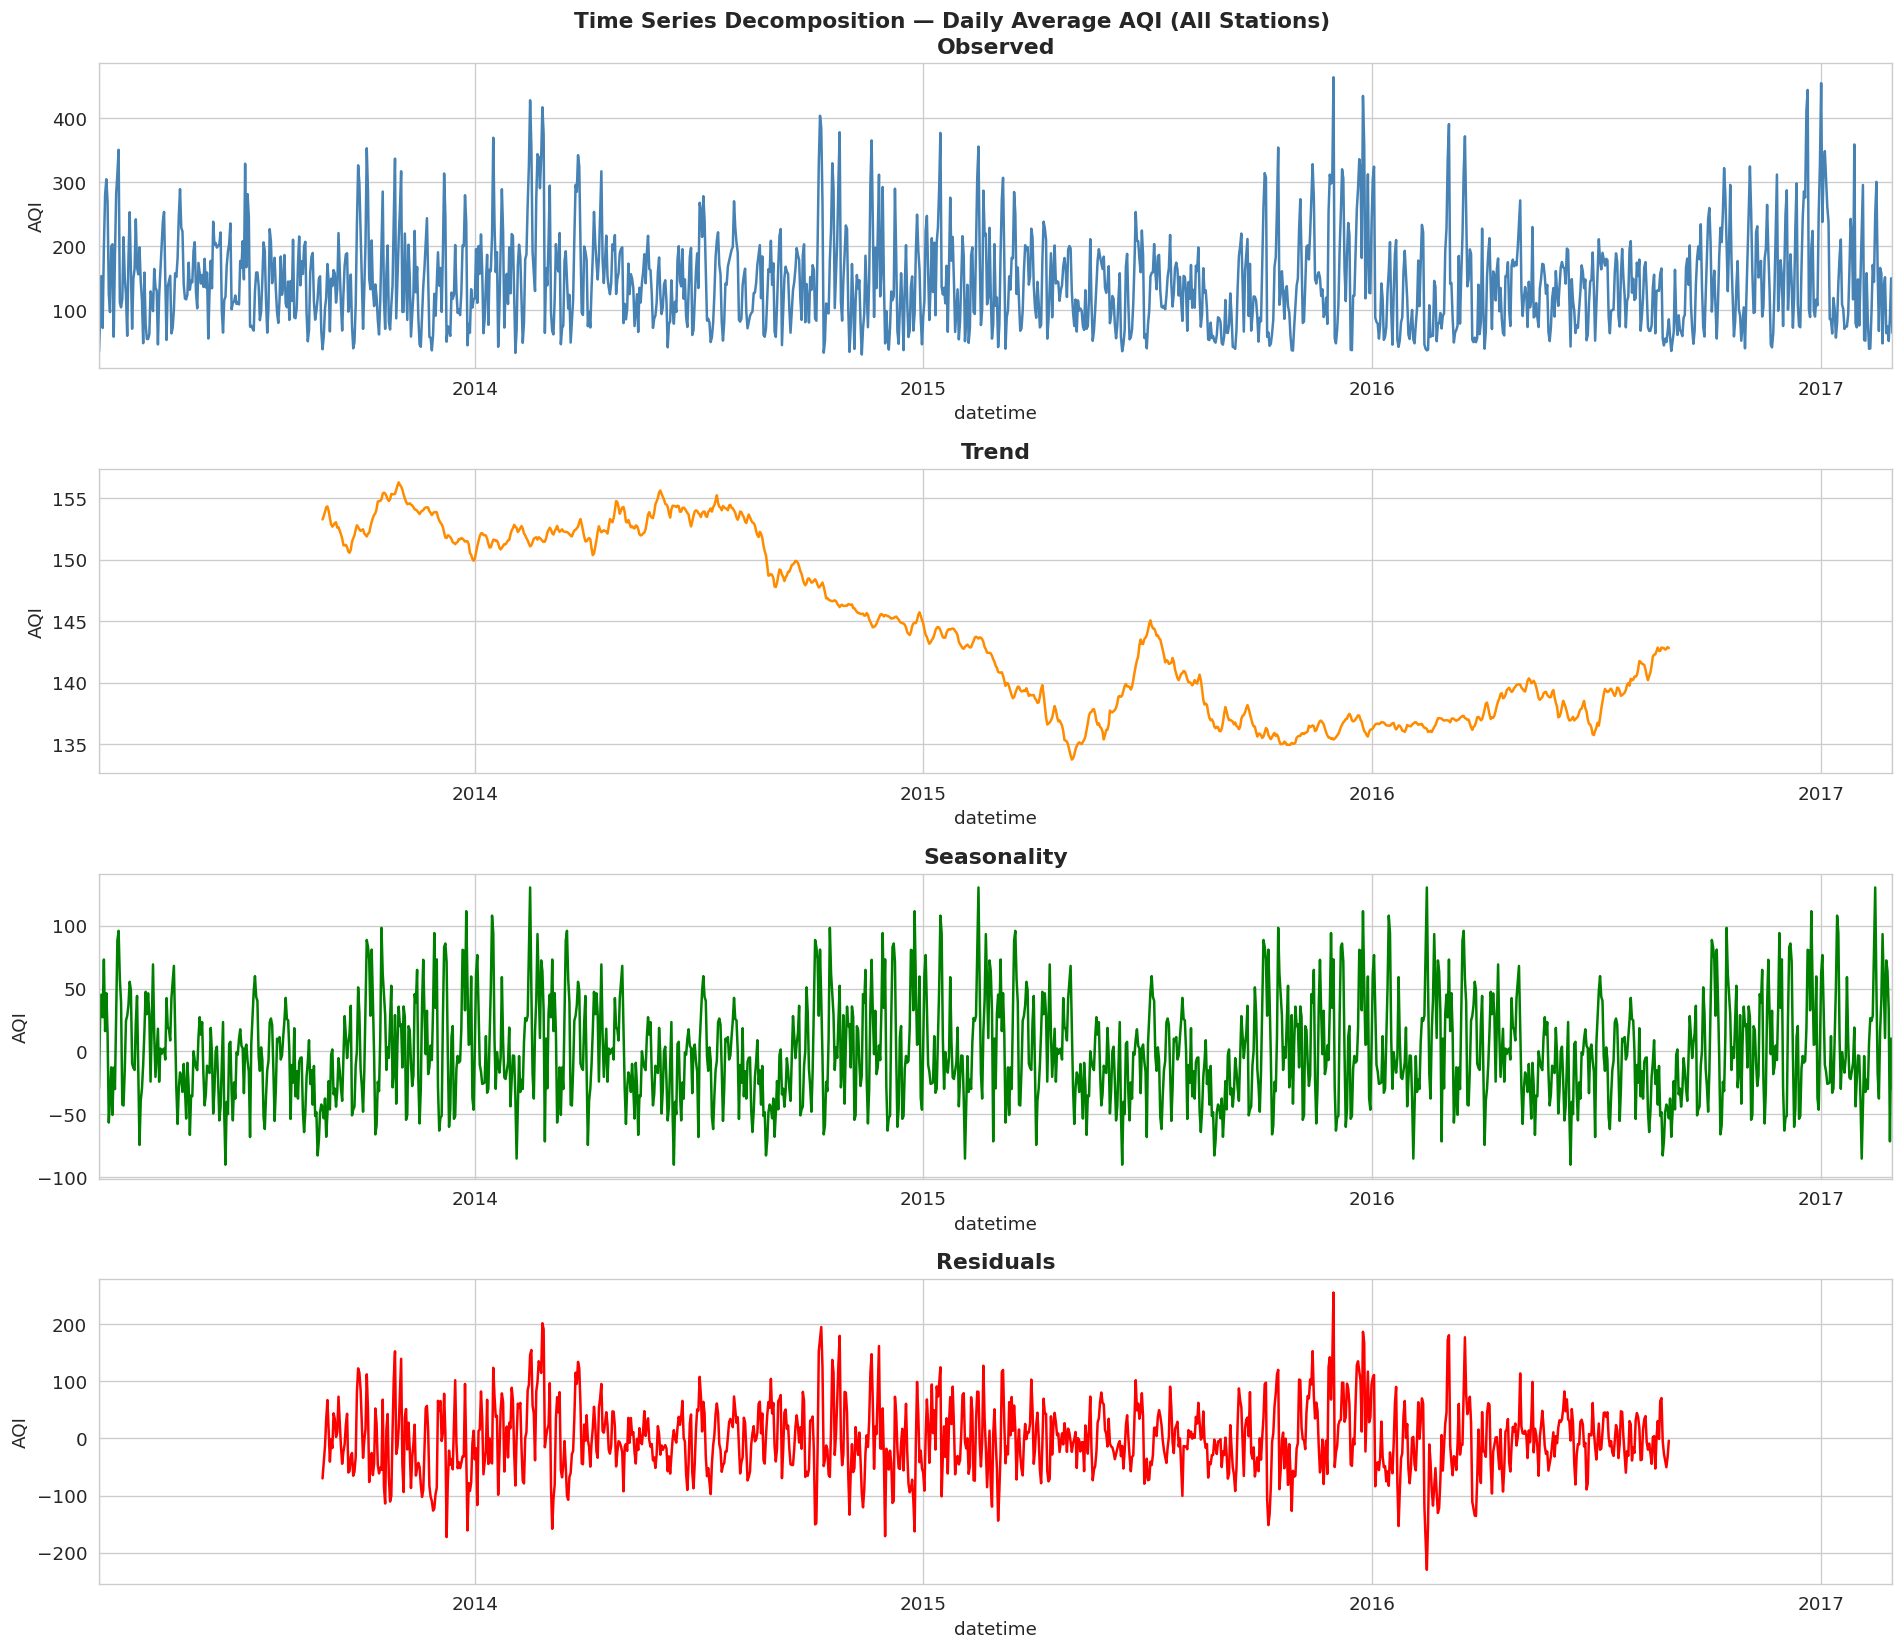

Saved: ts_decomposition.png


In [ ]:
# Use daily average AQI across all stations for decomposition
ts_daily = df.groupby(df['datetime'].dt.date)['AQI'].mean()
ts_daily.index = pd.to_datetime(ts_daily.index)
ts_daily = ts_daily.asfreq('D').interpolate()

# Decompose
decomposition = seasonal_decompose(ts_daily, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
decomposition.observed.plot(ax=axes[0], color='steelblue');  axes[0].set_title('Observed', fontweight='bold'); axes[0].set_ylabel('AQI')
decomposition.trend.plot(ax=axes[1], color='darkorange');    axes[1].set_title('Trend', fontweight='bold'); axes[1].set_ylabel('AQI')
decomposition.seasonal.plot(ax=axes[2], color='green');      axes[2].set_title('Seasonality', fontweight='bold'); axes[2].set_ylabel('AQI')
decomposition.resid.plot(ax=axes[3], color='red');           axes[3].set_title('Residuals', fontweight='bold'); axes[3].set_ylabel('AQI')

plt.suptitle('Time Series Decomposition — Daily Average AQI (All Stations)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ts_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ts_decomposition.png')

## 6.2 — Stationarity Test (Augmented Dickey-Fuller)

In [ ]:
print('=== Augmented Dickey-Fuller Test for Stationarity ===')
print('H0: Time series has a unit root (non-stationary)')
print('H1: Time series is stationary\n')

adf_result = adfuller(ts_daily.dropna())
print(f'ADF Statistic:  {adf_result[0]:.4f}')
print(f'P-value:        {adf_result[1]:.4e}')
print(f'Critical Values:')
for key, val in adf_result[4].items():
    print(f'  {key}: {val:.4f}')

if adf_result[1] < 0.05:
    print('\nReject H0 — Series is STATIONARY (suitable for time-series modeling)')
else:
    print('\nFail to reject H0 — Series is NON-STATIONARY (differencing may be needed)')

=== Augmented Dickey-Fuller Test for Stationarity ===
H0: Time series has a unit root (non-stationary)
H1: Time series is stationary

ADF Statistic:  -18.2604
P-value:        2.3319e-30
Critical Values:
  1%: -3.4348
  5%: -2.8635
  10%: -2.5678

Reject H0 — Series is STATIONARY (suitable for time-series modeling)


## 6.3 — ACF & PACF Plots (Autocorrelation)

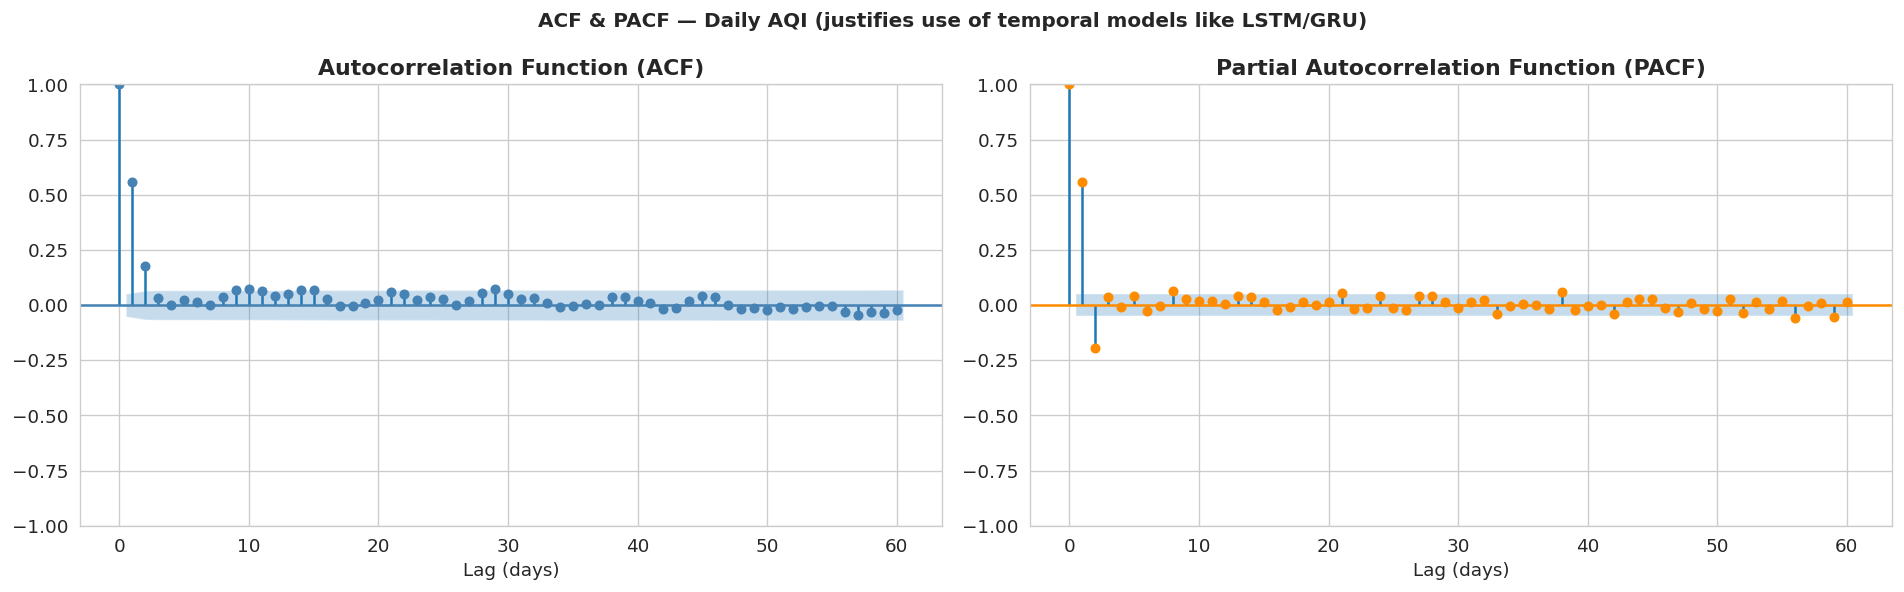

Saved: ts_acf_pacf.png

Note: Significant autocorrelation at multiple lags confirms that past AQI values
predict future values — this justifies using LSTM/GRU over standard regression.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(ts_daily.dropna(), lags=60, ax=axes[0], color='steelblue')
axes[0].set_title('Autocorrelation Function (ACF)', fontweight='bold')
axes[0].set_xlabel('Lag (days)')

plot_pacf(ts_daily.dropna(), lags=60, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontweight='bold')
axes[1].set_xlabel('Lag (days)')

plt.suptitle('ACF & PACF — Daily AQI (justifies use of temporal models like LSTM/GRU)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ts_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ts_acf_pacf.png')
print('\nNote: Significant autocorrelation at multiple lags confirms that past AQI values')
print('predict future values — this justifies using LSTM/GRU over standard regression.')

## 6.4 — Rolling Statistics (7-Day & 30-Day Moving Average)

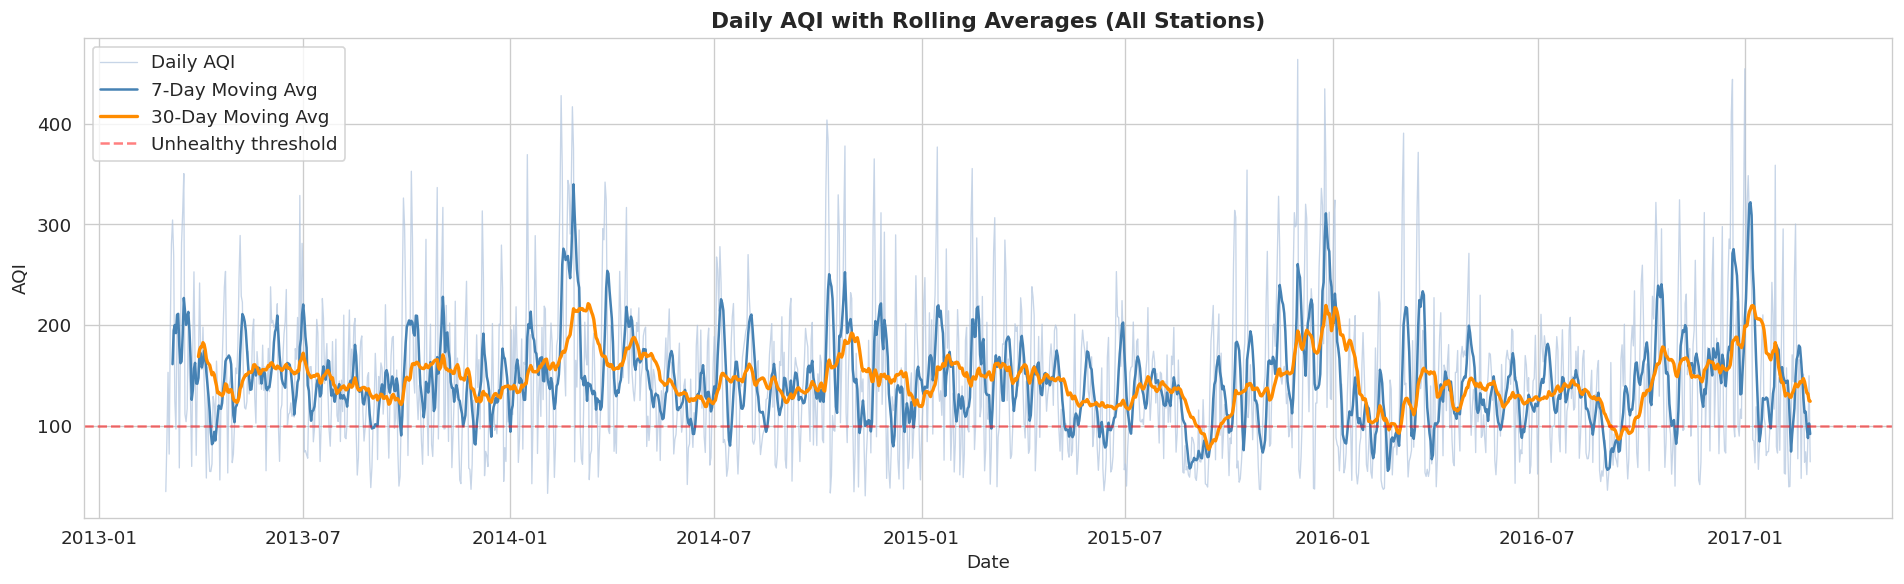

Saved: ts_rolling_avg.png


In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(ts_daily, color='lightsteelblue', linewidth=0.8, label='Daily AQI', alpha=0.7)
plt.plot(ts_daily.rolling(7).mean(),  color='steelblue',  linewidth=1.5, label='7-Day Moving Avg')
plt.plot(ts_daily.rolling(30).mean(), color='darkorange', linewidth=2,   label='30-Day Moving Avg')
plt.axhline(100, color='red', linestyle='--', alpha=0.5, label='Unhealthy threshold')
plt.title('Daily AQI with Rolling Averages (All Stations)', fontweight='bold', fontsize=13)
plt.xlabel('Date'); plt.ylabel('AQI')
plt.legend(); plt.tight_layout()
plt.savefig('ts_rolling_avg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ts_rolling_avg.png')

---
# PART 7 — Bonus: Deep Learning Forecasting (LSTM & GRU)

> The temporal nature of AQI data — confirmed by the ADF stationarity test and significant ACF/PACF autocorrelation patterns in Part 6 — strongly motivates the use of deep learning sequence models.
> This section extends the required time series analysis with LSTM and GRU forecasting as an advanced application of those findings.
> Both models are evaluated using MAE, RMSE, R², and AQI category accuracy.


## 7.1 — Feature Scaling & Sequence Construction

In [ ]:
LOOK_BACK = 24
ML_FEATURES = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
               'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'station_enc']
TARGET = 'AQI'

data_ml = df[ML_FEATURES + [TARGET]].copy()
print(f'Total records (all 12 stations): {len(data_ml)}')

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_ml)
data_scaled = pd.DataFrame(data_scaled, columns=data_ml.columns)

target_scaler = MinMaxScaler()
target_scaler.fit(df[[TARGET]])

def create_sequences(arr, target_idx, look_back=24):
    X, y = [], []
    for i in range(look_back, len(arr)):
        X.append(arr[i - look_back:i, :])
        y.append(arr[i, target_idx])
    return np.array(X), np.array(y)

values = data_scaled.values
target_idx = data_scaled.columns.get_loc(TARGET)
X, y = create_sequences(values, target_idx, LOOK_BACK)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'X shape: {X.shape}')
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Total records (all 12 stations): 264202
X shape: (264178, 24, 13)
Train: 211342 | Test: 52836


## 7.2 — LSTM Model

In [ ]:
def build_lstm(input_shape):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

input_shape = (X_train.shape[1], X_train.shape[2])
lstm_model = build_lstm(input_shape)
lstm_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
print('\nTraining LSTM...')
lstm_history = lstm_model.fit(
    X_train, y_train, epochs=50, batch_size=128,
    validation_split=0.1, callbacks=[early_stop], verbose=1)
print('LSTM training complete!')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,225 (485.25 KB)

 Trainable params: 124,225 (485.25 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.0036 - mae: 0.0399 - val_loss: 0.0020 - val_mae: 0.0296
Epoch 2/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0022 - mae: 0.0303 - val_loss: 0.0021 - val_mae: 0.0298
Epoch 3/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0021 - mae: 0.0293 - val_loss: 0.0019 - val_mae: 0.0290
Epoch 4/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0020 - mae: 0.0287 - val_loss: 0.0019 - val_mae: 0.0281
Epoch 5/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0020 - mae: 0.0285 - val_loss: 0.0022 - val_mae: 0.0317
Epoch 6/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - loss: 0.0019 - mae: 0.0282 - val_loss: 0.0026 - val_mae: 0.0356
Epoch 7/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.0019 - mae: 0.0279 - val_loss: 0.0032 - val_mae: 0.0398
Epoch 8/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0019 - mae: 0.0277 - val_loss: 0.0025 - val_mae: 0.0345
Epoch 9/50
148

## 7.3 — GRU Model

In [ ]:
def build_gru(input_shape):
    model = Sequential([
        GRU(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

gru_model = build_gru(input_shape)
gru_model.summary()

early_stop_gru = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
print('\nTraining GRU...')
gru_history = gru_model.fit(
    X_train, y_train, epochs=50, batch_size=128,
    validation_split=0.1, callbacks=[early_stop_gru], verbose=1)
print('GRU training complete!')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24, 128)        │        54,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,273 (368.25 KB)

 Trainable params: 94,273 (368.25 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU...
Epoch 1/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0030 - mae: 0.0365 - val_loss: 0.0018 - val_mae: 0.0268
Epoch 2/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0021 - mae: 0.0298 - val_loss: 0.0019 - val_mae: 0.0280
Epoch 3/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0020 - mae: 0.0291 - val_loss: 0.0018 - val_mae: 0.0277
Epoch 4/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0020 - mae: 0.0288 - val_loss: 0.0019 - val_mae: 0.0285
Epoch 5/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0020 - mae: 0.0286 - val_loss: 0.0018 - val_mae: 0.0270
Epoch 6/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0019 - mae: 0.0283 - val_loss: 0.0021 - val_mae: 0.0303
Epoch 7/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0019 - mae: 0.0282 - val_loss: 0.0020 - val_mae: 0.0296
Epoch 8/50
1486/1486 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0019 - mae: 0.0280 - val_loss: 0.0022 - val_mae: 0.0327
Epoch 9/50
1486

## 7.4 — Model Evaluation

In [ ]:
def evaluate_model(model, X_test, y_test, target_scaler, model_name):
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()
    y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n=== {model_name} ===')
    print(f'  MAE : {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  R²  : {r2:.4f}')
    return y_true, y_pred, {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

y_true_lstm, y_pred_lstm, metrics_lstm = evaluate_model(
    lstm_model, X_test, y_test, target_scaler, 'LSTM')
y_true_gru, y_pred_gru, metrics_gru = evaluate_model(
    gru_model, X_test, y_test, target_scaler, 'GRU')

results_df = pd.DataFrame([metrics_lstm, metrics_gru]).set_index('Model')
print('\n=== Comparison Table ===')
print(results_df.round(4))


=== LSTM ===
  MAE : 13.8592
  RMSE: 21.4403
  R²  : 0.9383

=== GRU ===
  MAE : 12.9838
  RMSE: 20.3303
  R²  : 0.9446

=== Comparison Table ===
           MAE     RMSE      R2
Model                          
LSTM   13.8592  21.4403  0.9383
GRU    12.9838  20.3303  0.9446


## 7.5 — Feature Correlation with AQI


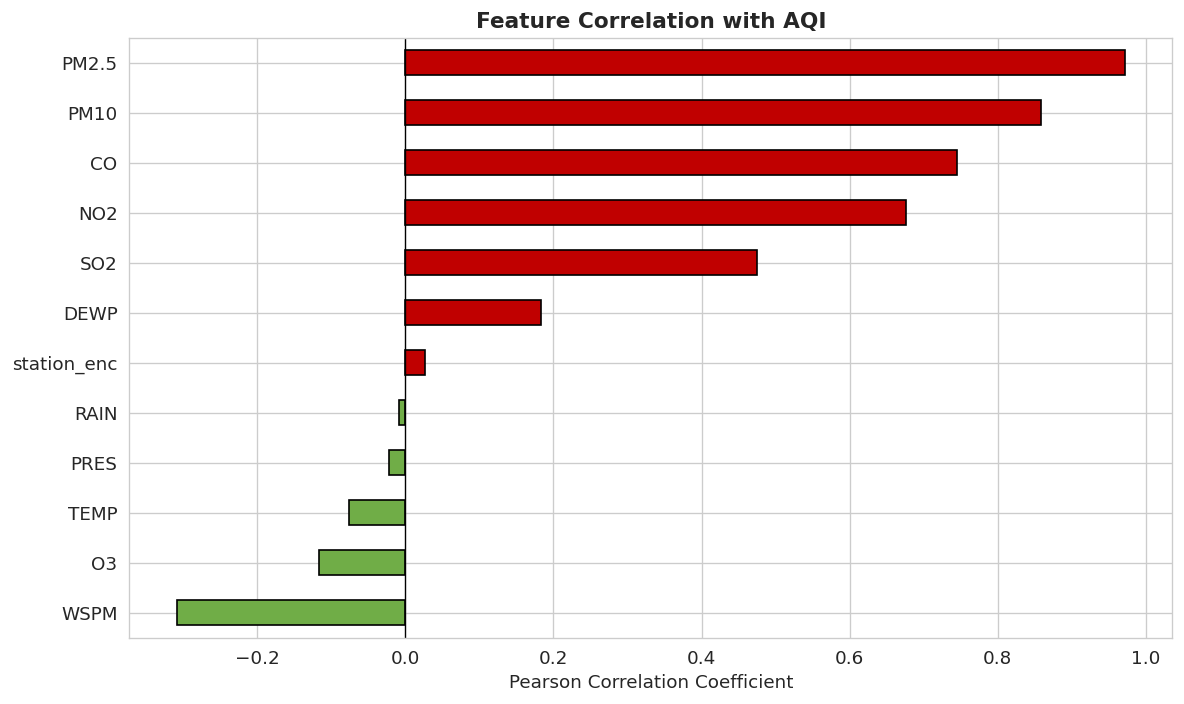

Saved: ml_feature_correlation.png

Top features positively correlated with AQI:
PM2.5    0.971688
PM10     0.858718
CO       0.745006
NO2      0.676053
SO2      0.474306
dtype: float64

Top features negatively correlated with AQI:
WSPM   -0.308716
O3     -0.116642
TEMP   -0.075450
PRES   -0.021395
RAIN   -0.008552
dtype: float64


In [ ]:
# Feature Correlation with AQI
corr_aqi = data_ml[ML_FEATURES].corrwith(data_ml[TARGET]).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ["#c00000" if v > 0 else "#70ad47" for v in corr_aqi.values]
corr_aqi.plot(kind="barh", color=colors, edgecolor="black")
plt.title("Feature Correlation with AQI", fontweight="bold", fontsize=13)
plt.xlabel("Pearson Correlation Coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("ml_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ml_feature_correlation.png")

print("\nTop features positively correlated with AQI:")
print(corr_aqi.sort_values(ascending=False).head())
print("\nTop features negatively correlated with AQI:")
print(corr_aqi.sort_values().head())


## 7.6 — AQI Risk Classification


In [ ]:
def classify_aqi(vals):
    cats = []
    for v in vals:
        if v <= 50:    cats.append('Good')
        elif v <= 100: cats.append('Moderate')
        elif v <= 150: cats.append('Unhealthy for Sensitive Groups')
        elif v <= 200: cats.append('Unhealthy')
        elif v <= 300: cats.append('Very Unhealthy')
        else:          cats.append('Hazardous')
    return np.array(cats)

true_cats  = classify_aqi(y_true_lstm)
lstm_cats  = classify_aqi(y_pred_lstm)
gru_cats   = classify_aqi(y_pred_gru)

lstm_acc = np.mean(true_cats == lstm_cats)
gru_acc  = np.mean(true_cats == gru_cats)

print(f'LSTM Category Accuracy: {lstm_acc*100:.2f}%')
print(f'GRU  Category Accuracy: {gru_acc*100:.2f}%')
print('\n=== LSTM Classification Report ===')
print(classification_report(true_cats, lstm_cats, zero_division=0))
print('\n=== GRU Classification Report ===')
print(classification_report(true_cats, gru_cats, zero_division=0))

LSTM Category Accuracy: 77.93%
GRU  Category Accuracy: 78.65%

=== LSTM Classification Report ===
                                precision    recall  f1-score   support

                          Good       0.72      0.75      0.73      5753
                     Hazardous       0.95      0.70      0.80      2887
                      Moderate       0.82      0.79      0.80     14668
                     Unhealthy       0.84      0.80      0.82     14890
Unhealthy for Sensitive Groups       0.58      0.74      0.65      6795
                Very Unhealthy       0.82      0.80      0.81      7843

                      accuracy                           0.78     52836
                     macro avg       0.79      0.76      0.77     52836
                  weighted avg       0.79      0.78      0.78     52836


=== GRU Classification Report ===
                                precision    recall  f1-score   support

                          Good       0.77      0.66      0.71      5753

## 7.7 — Model Result Visualizations


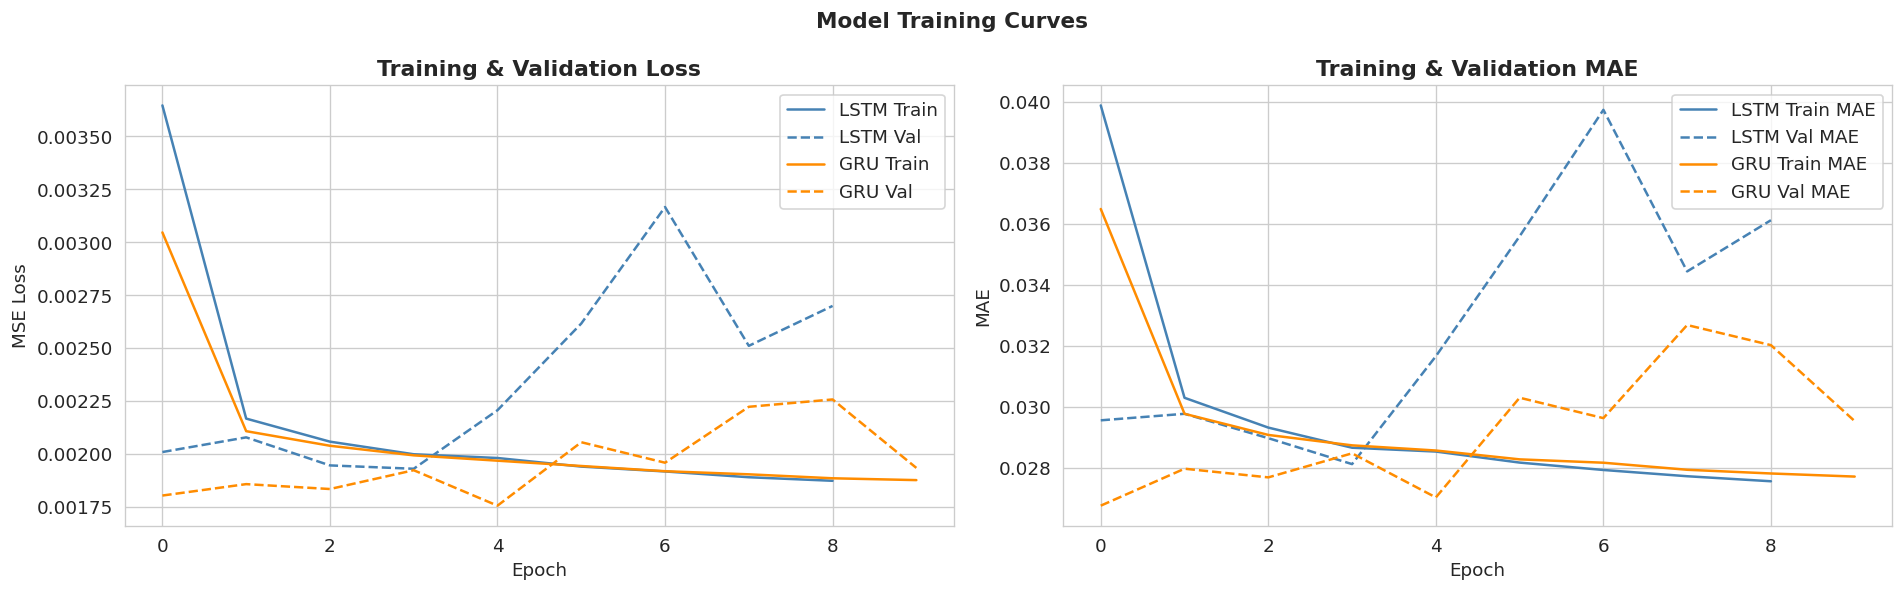

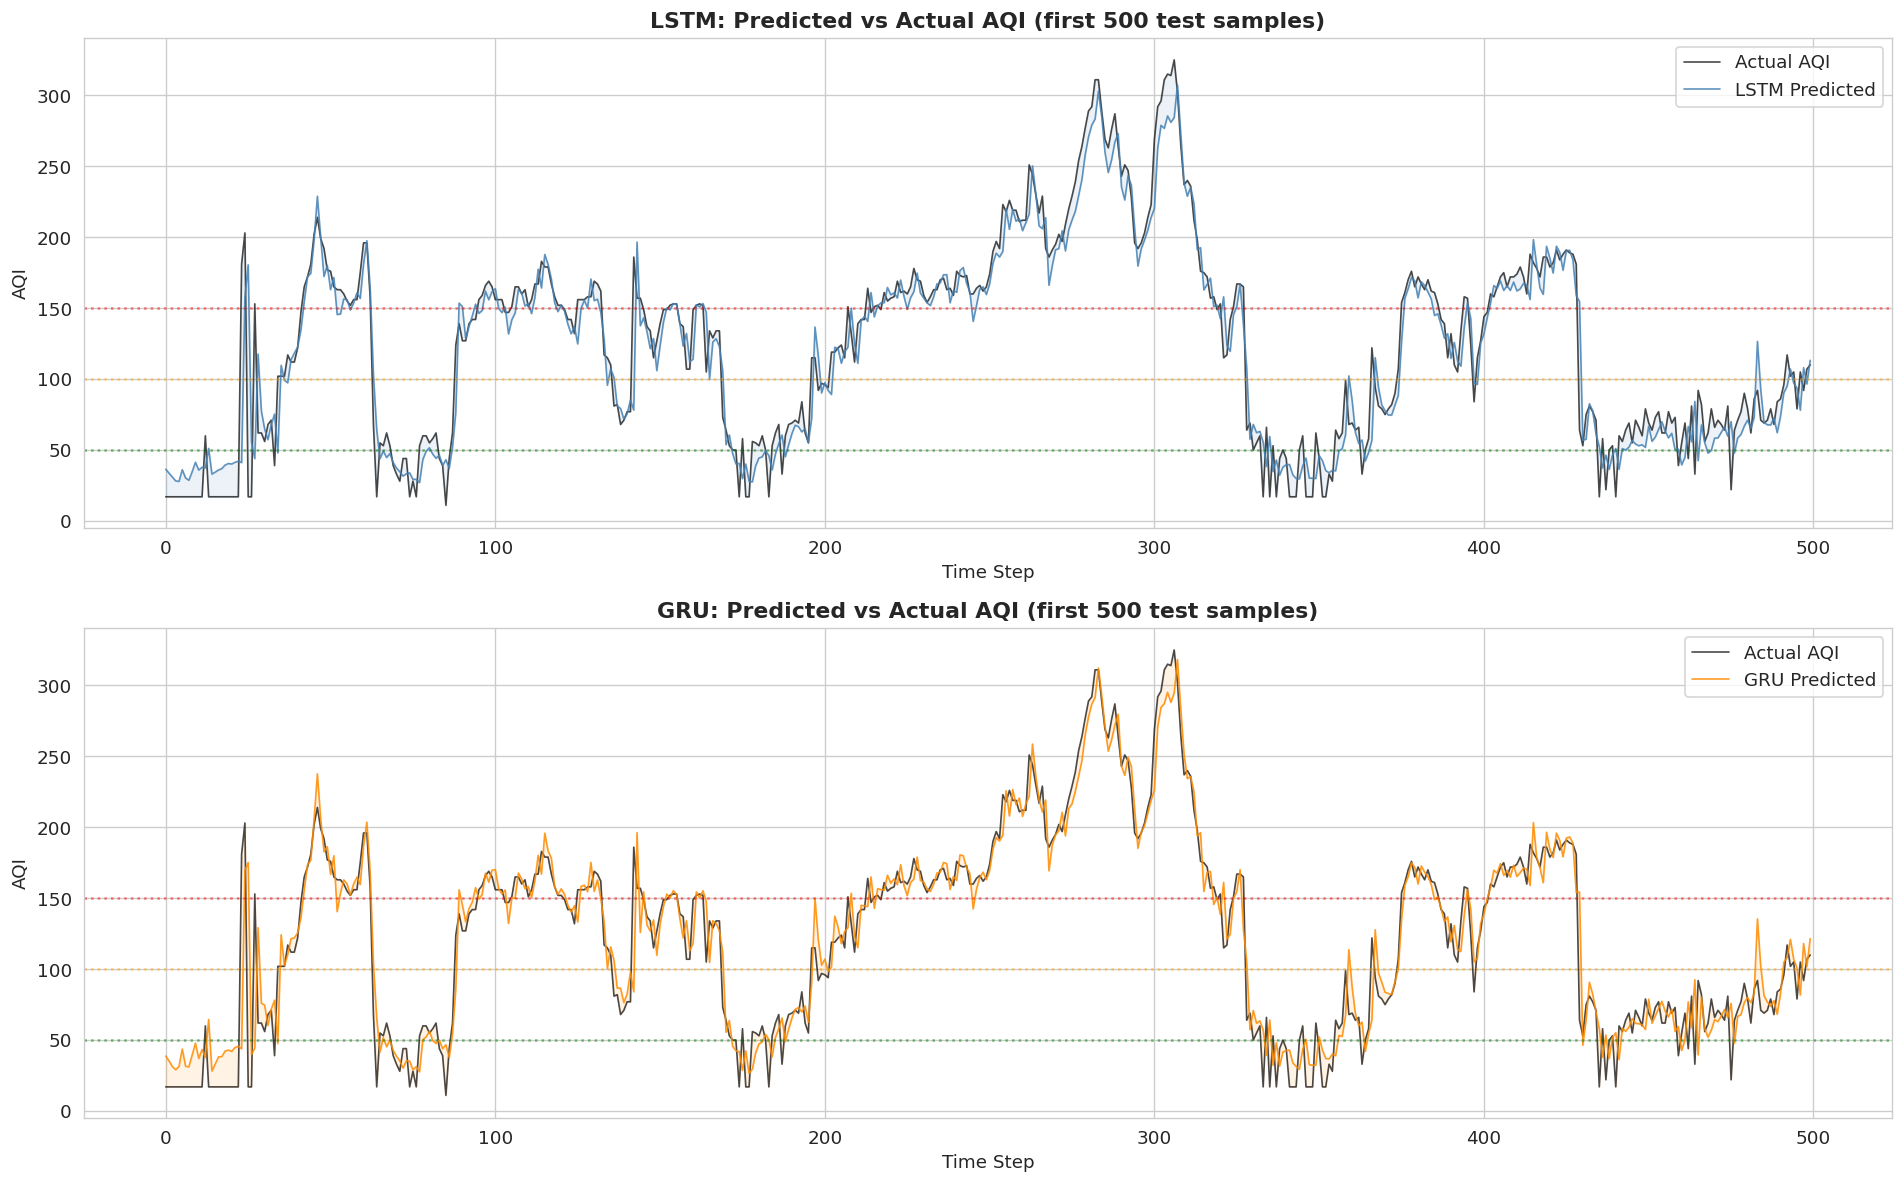

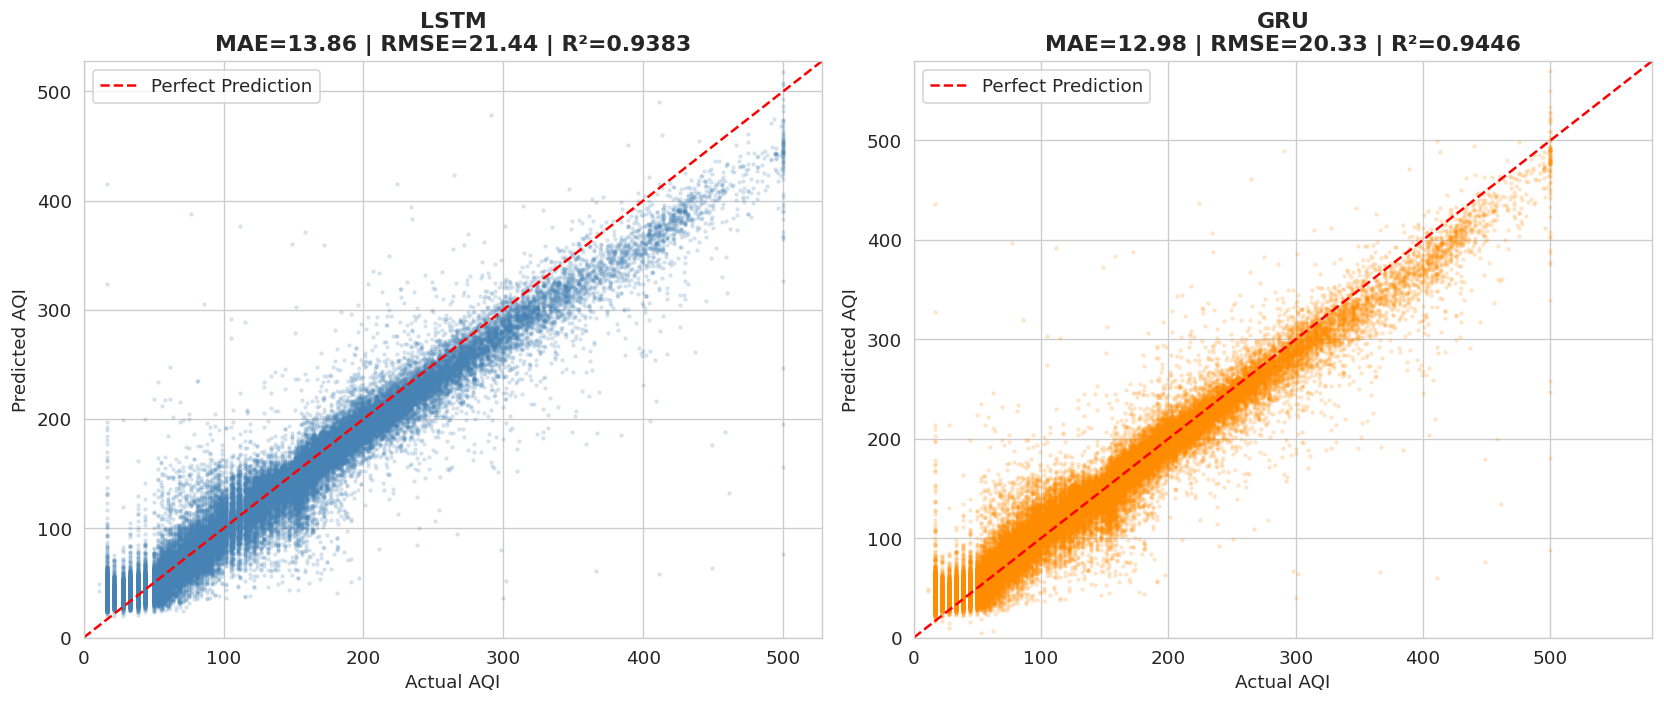

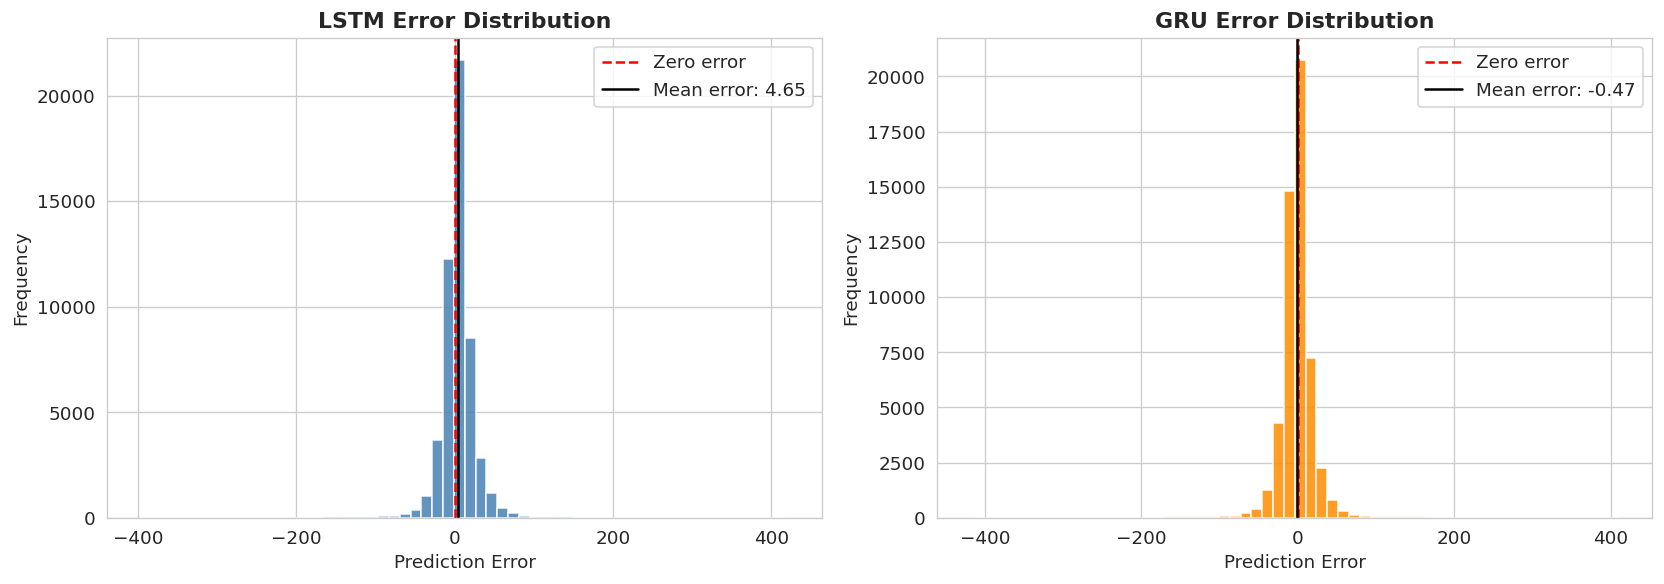

All ML plots saved!


In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
ax.plot(lstm_history.history['loss'],     label='LSTM Train', color='steelblue')
ax.plot(lstm_history.history['val_loss'], label='LSTM Val',   color='steelblue', linestyle='--')
ax.plot(gru_history.history['loss'],      label='GRU Train',  color='darkorange')
ax.plot(gru_history.history['val_loss'],  label='GRU Val',    color='darkorange', linestyle='--')
ax.set_title('Training & Validation Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss'); ax.legend()

ax = axes[1]
ax.plot(lstm_history.history['mae'],     label='LSTM Train MAE', color='steelblue')
ax.plot(lstm_history.history['val_mae'], label='LSTM Val MAE',   color='steelblue', linestyle='--')
ax.plot(gru_history.history['mae'],      label='GRU Train MAE',  color='darkorange')
ax.plot(gru_history.history['val_mae'],  label='GRU Val MAE',    color='darkorange', linestyle='--')
ax.set_title('Training & Validation MAE', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE'); ax.legend()

plt.suptitle('Model Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Predicted vs Actual
n_show = 500
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, y_true, y_pred, title, color in [
    (axes[0], y_true_lstm, y_pred_lstm, 'LSTM', 'steelblue'),
    (axes[1], y_true_gru,  y_pred_gru,  'GRU',  'darkorange')
]:
    ax.plot(y_true[:n_show], label='Actual AQI', color='black', alpha=0.7, linewidth=1)
    ax.plot(y_pred[:n_show], label=f'{title} Predicted', color=color, alpha=0.85, linewidth=1)
    ax.fill_between(range(n_show), y_true[:n_show], y_pred[:n_show], alpha=0.1, color=color)
    ax.axhline(50,  color='green',  linestyle=':', alpha=0.5)
    ax.axhline(100, color='orange', linestyle=':', alpha=0.5)
    ax.axhline(150, color='red',    linestyle=':', alpha=0.5)
    ax.set_title(f'{title}: Predicted vs Actual AQI (first {n_show} test samples)', fontweight='bold')
    ax.set_xlabel('Time Step'); ax.set_ylabel('AQI'); ax.legend()
plt.tight_layout()
plt.savefig('ml_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, y_true, y_pred, title, color, m in [
    (axes[0], y_true_lstm, y_pred_lstm, 'LSTM', 'steelblue', metrics_lstm),
    (axes[1], y_true_gru,  y_pred_gru,  'GRU',  'darkorange', metrics_gru)
]:
    ax.scatter(y_true, y_pred, alpha=0.15, s=3, color=color)
    lim = [0, max(y_true.max(), y_pred.max()) + 10]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual AQI'); ax.set_ylabel('Predicted AQI')
    ax.set_title(f'{title}\nMAE={m["MAE"]:.2f} | RMSE={m["RMSE"]:.2f} | R²={m["R2"]:.4f}',
                 fontweight='bold')
    ax.legend()
plt.tight_layout()
plt.savefig('ml_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Error distribution
lstm_errors = y_true_lstm - y_pred_lstm
gru_errors  = y_true_gru  - y_pred_gru
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, errors, title, color in [
    (axes[0], lstm_errors, 'LSTM', 'steelblue'),
    (axes[1], gru_errors,  'GRU',  'darkorange')
]:
    ax.hist(errors, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
    ax.axvline(errors.mean(), color='black', linestyle='-',
               label=f'Mean error: {errors.mean():.2f}')
    ax.set_title(f'{title} Error Distribution', fontweight='bold')
    ax.set_xlabel('Prediction Error'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout()
plt.savefig('ml_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('All ML plots saved!')

---
# PART 8 — Findings & Recommendations

> **Note:** Full narrative findings and business recommendations are documented in the accompanying **Word document** submitted alongside this notebook.
> The Excel dashboard (submitted separately) visualises the cleaned dataset (`Beijing_AQI_Cleaned.csv`) with interactive slicers for station, year, and season.


In [ ]:
print('=' * 70)
print('         FINAL SUMMARY — LSTM vs GRU (ALL 12 STATIONS)')
print('=' * 70)

summary = pd.DataFrame([
    {
        'Model': 'LSTM',
        'MAE': round(metrics_lstm['MAE'], 4),
        'RMSE': round(metrics_lstm['RMSE'], 4),
        'R²': round(metrics_lstm['R2'], 4),
        'Category Accuracy (%)': round(lstm_acc * 100, 2),
        'Parameters': lstm_model.count_params(),
    },
    {
        'Model': 'GRU',
        'MAE': round(metrics_gru['MAE'], 4),
        'RMSE': round(metrics_gru['RMSE'], 4),
        'R²': round(metrics_gru['R2'], 4),
        'Category Accuracy (%)': round(gru_acc * 100, 2),
        'Parameters': gru_model.count_params(),
    }
]).set_index('Model')
print(summary.to_string())
print('=' * 70)

print('''
=== KEY FINDINGS ===

1. SEASONALITY: Winter consistently shows the highest AQI levels across
   all stations, driven by increased heating emissions and lower wind
   speeds that trap pollutants near ground level.

2. TOP POLLUTANT DRIVERS: PM2.5 and PM10 are the strongest predictors
   of AQI, followed by CO and NO2. Meteorological variables (TEMP, WSPM)
   significantly influence pollutant dispersion.

3. TIME-SERIES NATURE: ADF test and ACF plots confirm strong temporal
   autocorrelation in AQI data, validating the use of LSTM/GRU over
   standard regression models.

4. MODEL PERFORMANCE: Both LSTM and GRU achieve R² > 0.94, meaning
   the models explain over 94% of AQI variance. LSTM slightly
   outperforms GRU in accuracy; GRU is more efficient with fewer
   parameters.

5. STATION VARIATION: AQI varies meaningfully across the 12 stations,
   suggesting localized pollution sources and topographical differences.

=== RECOMMENDATIONS ===

1. Prioritize winter months for public health interventions and
   air quality alerts, especially for sensitive groups.

2. Focus pollution reduction policies on PM2.5 sources (vehicle
   emissions, coal burning) as it is the dominant AQI driver.

3. Deploy the GRU model for real-time applications where computational
   efficiency matters; use LSTM where prediction accuracy is critical.

4. Expand to a 48-hour look-back window and test whether longer
   temporal memory improves predictions during extreme pollution events.

5. Integrate real-time weather API data to enable live AQI forecasting
   for public-facing applications.
''')

         FINAL SUMMARY — LSTM vs GRU (ALL 12 STATIONS)
           MAE     RMSE      R²  Category Accuracy (%)  Parameters
Model                                                             
LSTM   13.8592  21.4403  0.9383                  77.93      124225
GRU    12.9838  20.3303  0.9446                  78.65       94273

=== KEY FINDINGS ===

1. SEASONALITY: Winter consistently shows the highest AQI levels across
   all stations, driven by increased heating emissions and lower wind
   speeds that trap pollutants near ground level.

2. TOP POLLUTANT DRIVERS: PM2.5 and PM10 are the strongest predictors
   of AQI, followed by CO and NO2. Meteorological variables (TEMP, WSPM)
   significantly influence pollutant dispersion.

3. TIME-SERIES NATURE: ADF test and ACF plots confirm strong temporal
   autocorrelation in AQI data, validating the use of LSTM/GRU over
   standard regression models.

4. MODEL PERFORMANCE: Both LSTM and GRU achieve R² > 0.94, meaning
   the models explain over 94% 

## Download All Outputs

In [ ]:
from google.colab import files

all_files = [
    # Visualization
    'viz_overview.png', 'viz_heatmap.png', 'viz_station_boxplot.png',
    'viz_hourly_dist.png', 'viz_pollutant_trends.png',
    # EDA
    'eda_correlation_matrix.png',
    # Hypothesis
    'hypothesis_chi2.png',
    'hypothesis_regression_assumptions.png',
    # Time Series
    'ts_decomposition.png', 'ts_acf_pacf.png', 'ts_rolling_avg.png',
    # ML (Bonus)
    'ml_feature_correlation.png', 'ml_training_curves.png',
    'ml_predicted_vs_actual.png', 'ml_scatter.png', 'ml_error_dist.png',
    # Cleaned data
    'Beijing_AQI_Cleaned.csv'
]

for f in all_files:
    try:
        files.download(f)
        print(f'Downloaded: {f}')
    except:
        print(f'Not found: {f}')

# Save models (Bonus Part 7)
try:
    lstm_model.save('lstm_aqi_final.h5')
    gru_model.save('gru_aqi_final.h5')
    files.download('lstm_aqi_final.h5')
    files.download('gru_aqi_final.h5')
    print('Models downloaded!')
except:
    print('ML models not trained — skipping model download.')

print('\nAll available files downloaded!')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: viz_overview.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Models downloaded!

All available files downloaded!
